In [2]:
# ============================================================
# FINAL BDD100K TEST EVALUATION
# CELL 2 — TEST IQA FEATURES + POLICY PREDICTIONS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import joblib


print("=" * 70)
print("FINAL BDD100K TEST EVALUATION")
print("CELL 2 — IQA FEATURES + POLICY PREDICTIONS")
print("=" * 70)


# ============================================================
# 1. PATHS
# ============================================================

DATASET_PATH = Path(
    r"E:\ML_Project\datasets\bdd100k_original_yolo"
)

TEST_IMAGES_PATH = (
    DATASET_PATH / "test" / "images"
)

IQA_ALL_PATH = Path(
    r"E:\ML_Project\results\iqa_features_all.csv"
)

HIGH_CONF_MODEL_DIR = Path(
    r"E:\ML_Project\results\policy_models_high_confidence"
)

OUTPUT_DIR = Path(
    r"E:\ML_Project\results\oracle_labels"
    r"\final_test_20k"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "test_policy_predictions_high_confidence_20000.csv"
)


# ============================================================
# 2. IQA FEATURE COLUMNS
# ============================================================

FEATURE_COLUMNS = [

    "mean_brightness",
    "brightness_std",
    "rms_contrast",
    "laplacian_variance",
    "tenengrad",
    "entropy",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "mean_saturation",
    "saturation_std",
    "colorfulness",
    "edge_density",
    "noise_proxy"

]


ACTION_NAMES = {

    0: "Identity",
    1: "CLAHE",
    2: "Gamma",
    3: "Dehazing",
    4: "Denoising"

}


# ============================================================
# 3. LOAD IQA FEATURES
# ============================================================

print("\n" + "=" * 70)
print("LOADING IQA FEATURES")
print("=" * 70)

if not IQA_ALL_PATH.exists():

    raise FileNotFoundError(
        f"IQA feature file not found:\n{IQA_ALL_PATH}"
    )

iqa_all = pd.read_csv(
    IQA_ALL_PATH
)

print(
    f"Total IQA rows : {len(iqa_all):,}"
)

print(
    f"Columns        : {len(iqa_all.columns)}"
)


# ============================================================
# 4. IDENTIFY TEST IMAGES
# ============================================================

test_image_paths = sorted(
    [
        p for p in TEST_IMAGES_PATH.glob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]
)

test_image_names = {
    p.name for p in test_image_paths
}

print(
    f"Test images    : {len(test_image_paths):,}"
)


# ============================================================
# 5. FIND TEST IQA ROWS
# ============================================================

print("\n" + "=" * 70)
print("MATCHING TEST IMAGES WITH IQA FEATURES")
print("=" * 70)

if "image_name" not in iqa_all.columns:

    raise KeyError(
        "Expected 'image_name' column "
        "in IQA feature file."
    )

test_iqa = iqa_all[
    iqa_all["image_name"].isin(test_image_names)
].copy()

test_iqa = (
    test_iqa
    .drop_duplicates(
        subset=["image_name"]
    )
    .reset_index(drop=True)
)

print(
    f"Matched IQA rows : {len(test_iqa):,}"
)

if len(test_iqa) != 20_000:

    missing = (
        test_image_names
        - set(test_iqa["image_name"])
    )

    print(
        f"\n⚠ WARNING: "
        f"{len(missing):,} test images "
        f"do not have IQA features."
    )

    if len(missing) > 0:

        print(
            "First missing images:"
        )

        for name in list(missing)[:10]:

            print(
                f"  {name}"
            )

    raise ValueError(
        "Test IQA feature count is not 20,000."
    )

else:

    print(
        "✓ All 20,000 test images matched."
    )


# ============================================================
# 6. CHECK IQA FEATURES
# ============================================================

print("\n" + "=" * 70)
print("CHECKING IQA FEATURE QUALITY")
print("=" * 70)

missing_feature_count = (
    test_iqa[FEATURE_COLUMNS]
    .isna()
    .sum()
    .sum()
)

print(
    f"Missing feature values : "
    f"{missing_feature_count}"
)

if missing_feature_count != 0:

    raise ValueError(
        "Missing IQA feature values detected."
    )

print(
    "✓ No missing IQA features"
)


# ============================================================
# 7. LOAD FROZEN HIGH-CONFIDENCE REWARD MODELS
# ============================================================

print("\n" + "=" * 70)
print("LOADING FROZEN HIGH-CONFIDENCE REWARD MODELS")
print("=" * 70)

reward_actions = {

    1: "clahe",
    2: "gamma",
    3: "dehazing",
    4: "denoising"

}

models = {}

for action_id, action_name in reward_actions.items():

    model_path = (
        HIGH_CONF_MODEL_DIR
        /
        f"{action_name}_reward_lgbm_high_confidence.pkl"
    )

    if not model_path.exists():

        raise FileNotFoundError(
            f"Missing model:\n{model_path}"
        )

    models[action_id] = joblib.load(
        model_path
    )

    print(
        f"✓ Loaded {ACTION_NAMES[action_id]} "
        f"reward model"
    )


# ============================================================
# 8. PREPARE FEATURES
# ============================================================

X_test = test_iqa[
    FEATURE_COLUMNS
].copy()

print("\n" + "=" * 70)
print("PREPARING TEST FEATURES")
print("=" * 70)

print(
    f"Feature matrix shape : {X_test.shape}"
)

print(
    "✓ Using ONLY the 13 IQA features"
)

print(
    "✓ No ground-truth labels used"
)

print(
    "✓ No F1 / reward information used"
)


# ============================================================
# 9. PREDICT REWARDS
# ============================================================

print("\n" + "=" * 70)
print("PREDICTING TEST REWARDS")
print("=" * 70)

prediction_df = test_iqa[
    [
        "image_name",
        "image_path"
    ]
].copy()

prediction_df = prediction_df.rename(
    columns={
        "image_name": "image"
    }
)


for action_id, model in models.items():

    action_name = ACTION_NAMES[action_id]

    predicted_reward = model.predict(
        X_test
    )

    prediction_df[
        f"predicted_{action_name.lower()}_reward"
    ] = predicted_reward

    print(
        f"✓ Predicted {action_name} reward"
    )


# ============================================================
# 10. BUILD ACTION MATRIX
# ============================================================

reward_columns = [

    "predicted_clahe_reward",
    "predicted_gamma_reward",
    "predicted_dehazing_reward",
    "predicted_denoising_reward"

]

reward_matrix = prediction_df[
    reward_columns
].to_numpy()


# ============================================================
# 11. SELECT BEST ACTION
# ============================================================

best_enhancement_index = np.argmax(
    reward_matrix,
    axis=1
)

best_enhancement_reward = np.max(
    reward_matrix,
    axis=1
)

# Enhancement index 0-3 corresponds to action IDs 1-4
predicted_action_id = (
    best_enhancement_index + 1
)

# Identity is selected when no enhancement
# has a sufficiently positive predicted reward.
#
# Conservative policy:
# if all predicted rewards <= 0,
# choose Identity.

max_reward = best_enhancement_reward.copy()

identity_mask = (
    max_reward <= 0
)

predicted_action_id[
    identity_mask
] = 0

# Final predicted reward
predicted_reward = np.where(
    identity_mask,
    0.0,
    best_enhancement_reward
)


# ============================================================
# 12. PREDICTED MARGIN
# ============================================================

sorted_rewards = np.sort(
    reward_matrix,
    axis=1
)

best_reward = (
    sorted_rewards[:, -1]
)

second_best_reward = (
    sorted_rewards[:, -2]
)

predicted_margin = (
    best_reward
    - second_best_reward
)


# ============================================================
# 13. ADD POLICY RESULTS
# ============================================================

prediction_df[
    "predicted_action_id"
] = predicted_action_id

prediction_df[
    "predicted_action"
] = [
    ACTION_NAMES[int(x)]
    for x in predicted_action_id
]

prediction_df[
    "predicted_reward"
] = predicted_reward

prediction_df[
    "predicted_margin"
] = predicted_margin


# ============================================================
# 14. SORT BY IMAGE
# ============================================================

prediction_df = (
    prediction_df
    .sort_values("image")
    .reset_index(drop=True)
)


# ============================================================
# 15. SAVE
# ============================================================

prediction_df.to_csv(
    OUTPUT_PATH,
    index=False
)


# ============================================================
# 16. ACTION DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("TEST POLICY ACTION DISTRIBUTION")
print("=" * 70)

action_counts = (
    prediction_df[
        "predicted_action_id"
    ]
    .value_counts()
    .sort_index()
)

for action_id in range(5):

    count = int(
        action_counts.get(
            action_id,
            0
        )
    )

    percentage = (
        count
        / len(prediction_df)
        * 100
    )

    print(
        f"{ACTION_NAMES[action_id]:<12}"
        f"{count:>7,}"
        f" ({percentage:6.2f}%)"
    )


# ============================================================
# 17. REWARD STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("TEST PREDICTED REWARD STATISTICS")
print("=" * 70)

for column in reward_columns:

    values = prediction_df[
        column
    ]

    print(
        f"{column.replace('predicted_', '').replace('_reward', '').title():<12}"
        f" mean = {values.mean():.6f}"
        f" | std = {values.std():.6f}"
    )


print(
    f"\nMean best enhancement reward : "
    f"{best_enhancement_reward.mean():.6f}"
)

print(
    f"Median best enhancement reward : "
    f"{np.median(best_enhancement_reward):.6f}"
)

print(
    f"Mean predicted margin : "
    f"{predicted_margin.mean():.6f}"
)


# ============================================================
# 18. FINAL CHECKS
# ============================================================

print("\n" + "=" * 70)
print("FINAL SANITY CHECK")
print("=" * 70)

print(
    f"Prediction rows : "
    f"{len(prediction_df):,}"
)

print(
    f"Unique images   : "
    f"{prediction_df['image'].nunique():,}"
)

if len(prediction_df) != 20_000:

    raise ValueError(
        "Prediction count is not 20,000."
    )

if prediction_df["image"].nunique() != 20_000:

    raise ValueError(
        "Duplicate/missing test images detected."
    )

print(
    "✓ Exactly 20,000 unique test images"
)

print(
    "✓ Test labels were NOT used"
)

print(
    "✓ YOLO inference was NOT performed"
)

print(
    "✓ Frozen policy models only"
)


# ============================================================
# 19. COMPLETED
# ============================================================

print("\n" + "=" * 70)
print("CELL 2 COMPLETED")
print("=" * 70)

print(
    "\nSaved to:"
)

print(
    OUTPUT_PATH
)

print(
    "\nNext:"
)

print(
    "Cell 3 → Run frozen YOLO26n Identity baseline "
    "on all 20K test images."
)

FINAL BDD100K TEST EVALUATION
CELL 2 — IQA FEATURES + POLICY PREDICTIONS

LOADING IQA FEATURES
Total IQA rows : 100,000
Columns        : 16
Test images    : 20,000

MATCHING TEST IMAGES WITH IQA FEATURES
Matched IQA rows : 20,000
✓ All 20,000 test images matched.

CHECKING IQA FEATURE QUALITY
Missing feature values : 0
✓ No missing IQA features

LOADING FROZEN HIGH-CONFIDENCE REWARD MODELS
✓ Loaded CLAHE reward model
✓ Loaded Gamma reward model
✓ Loaded Dehazing reward model
✓ Loaded Denoising reward model

PREPARING TEST FEATURES
Feature matrix shape : (20000, 13)
✓ Using ONLY the 13 IQA features
✓ No ground-truth labels used
✓ No F1 / reward information used

PREDICTING TEST REWARDS
✓ Predicted CLAHE reward
✓ Predicted Gamma reward
✓ Predicted Dehazing reward
✓ Predicted Denoising reward

TEST POLICY ACTION DISTRIBUTION
Identity      2,315 ( 11.58%)
CLAHE         6,381 ( 31.91%)
Gamma         1,729 (  8.64%)
Dehazing      2,382 ( 11.91%)
Denoising     7,193 ( 35.97%)

TEST PREDICTED 

In [3]:
# ============================================================
# FINAL BDD100K TEST EVALUATION
# CELL 3 — IDENTITY / ORIGINAL YOLO26n BASELINE
# ============================================================

from pathlib import Path
import time
import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO


print("=" * 70)
print("FINAL BDD100K TEST EVALUATION")
print("CELL 3 — IDENTITY / ORIGINAL YOLO26n BASELINE")
print("=" * 70)


# ============================================================
# 1. PATHS
# ============================================================

DATASET_PATH = Path(
    r"E:\ML_Project\datasets\bdd100k_original_yolo"
)

TEST_IMAGES_PATH = (
    DATASET_PATH / "test" / "images"
)

TEST_LABELS_PATH = (
    DATASET_PATH / "test" / "labels"
)

MODEL_PATH = Path(
    r"E:\ML_Project\results\yolo26_baseline"
    r"\bdd100k_original_yolo_yolo26n_baseline_30ep"
    r"\weights\best.pt"
)

OUTPUT_DIR = Path(
    r"E:\ML_Project\results\oracle_labels"
    r"\final_test_20k"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "identity_test_detection_results_20000.csv"
)


# ============================================================
# 2. PARAMETERS
# ============================================================

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
IMAGE_SIZE = 640

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"


# ============================================================
# 3. LOAD MODEL
# ============================================================

print("\n" + "=" * 70)
print("LOADING FROZEN YOLO26n")
print("=" * 70)

model = YOLO(
    str(MODEL_PATH)
)

print(
    f"✓ Model loaded"
)

print(
    f"✓ Device: {DEVICE}"
)


# ============================================================
# 4. GET TEST IMAGES
# ============================================================

test_images = sorted(
    [
        p for p in TEST_IMAGES_PATH.glob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]
)

print("\n" + "=" * 70)
print("TEST DATASET")
print("=" * 70)

print(
    f"Test images: {len(test_images):,}"
)

if len(test_images) != 20_000:

    raise ValueError(
        f"Expected 20,000 test images, "
        f"found {len(test_images):,}"
    )


# ============================================================
# 5. LOAD GROUND TRUTH
# ============================================================

def load_yolo_labels(label_path):

    boxes = []

    if not label_path.exists():
        return boxes

    with open(
        label_path,
        "r"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(
                parts[0]
            )

            x_center = float(
                parts[1]
            )

            y_center = float(
                parts[2]
            )

            width = float(
                parts[3]
            )

            height = float(
                parts[4]
            )

            boxes.append(
                [
                    class_id,
                    x_center,
                    y_center,
                    width,
                    height
                ]
            )

    return boxes


# ============================================================
# 6. IOU FUNCTION
# ============================================================

def calculate_iou(box1, box2):

    # box format:
    # [x1, y1, x2, y2]

    x1 = max(
        box1[0],
        box2[0]
    )

    y1 = max(
        box1[1],
        box2[1]
    )

    x2 = min(
        box1[2],
        box2[2]
    )

    y2 = min(
        box1[3],
        box2[3]
    )

    intersection_width = max(
        0.0,
        x2 - x1
    )

    intersection_height = max(
        0.0,
        y2 - y1
    )

    intersection = (
        intersection_width
        *
        intersection_height
    )

    area1 = (
        max(
            0.0,
            box1[2] - box1[0]
        )
        *
        max(
            0.0,
            box1[3] - box1[1]
        )
    )

    area2 = (
        max(
            0.0,
            box2[2] - box2[0]
        )
        *
        max(
            0.0,
            box2[3] - box2[1]
        )
    )

    union = (
        area1
        +
        area2
        -
        intersection
    )

    if union <= 0:
        return 0.0

    return intersection / union


# ============================================================
# 7. CONVERT YOLO BOX TO PIXEL BOX
# ============================================================

def yolo_to_pixel_box(
    yolo_box,
    image_width,
    image_height
):

    class_id = yolo_box[0]

    xc = yolo_box[1] * image_width
    yc = yolo_box[2] * image_height
    w = yolo_box[3] * image_width
    h = yolo_box[4] * image_height

    x1 = xc - w / 2
    y1 = yc - h / 2
    x2 = xc + w / 2
    y2 = yc + h / 2

    return (
        int(class_id),
        [
            x1,
            y1,
            x2,
            y2
        ]
    )


# ============================================================
# 8. DETECTION MATCHING
# ============================================================

def calculate_detection_metrics(
    predictions,
    ground_truths,
    image_width,
    image_height
):

    gt_boxes = []

    for gt in ground_truths:

        class_id, box = (
            yolo_to_pixel_box(
                gt,
                image_width,
                image_height
            )
        )

        gt_boxes.append(
            (
                class_id,
                box
            )
        )


    pred_boxes = []

    for pred in predictions:

        class_id = int(
            pred[0]
        )

        x1 = float(
            pred[1]
        )

        y1 = float(
            pred[2]
        )

        x2 = float(
            pred[3]
        )

        y2 = float(
            pred[4]
        )

        pred_boxes.append(
            (
                class_id,
                [
                    x1,
                    y1,
                    x2,
                    y2
                ]
            )
        )


    # --------------------------------------------------------
    # Class-aware one-to-one matching
    # --------------------------------------------------------

    matched_gt = set()
    matched_pred = set()

    candidate_matches = []

    for pred_index, (
        pred_class,
        pred_box
    ) in enumerate(pred_boxes):

        for gt_index, (
            gt_class,
            gt_box
        ) in enumerate(gt_boxes):

            if pred_class != gt_class:
                continue

            iou = calculate_iou(
                pred_box,
                gt_box
            )

            if iou >= IOU_THRESHOLD:

                candidate_matches.append(
                    (
                        iou,
                        pred_index,
                        gt_index
                    )
                )


    # Highest IoU first
    candidate_matches.sort(
        reverse=True
    )


    tp = 0

    for (
        iou,
        pred_index,
        gt_index
    ) in candidate_matches:

        if pred_index in matched_pred:
            continue

        if gt_index in matched_gt:
            continue

        matched_pred.add(
            pred_index
        )

        matched_gt.add(
            gt_index
        )

        tp += 1


    fp = (
        len(pred_boxes)
        -
        tp
    )

    fn = (
        len(gt_boxes)
        -
        tp
    )


    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall
        /
        (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )


    return (
        tp,
        fp,
        fn,
        precision,
        recall,
        f1
    )


# ============================================================
# 9. RUN BASELINE
# ============================================================

print("\n" + "=" * 70)
print("RUNNING IDENTITY BASELINE")
print("=" * 70)

results = []

total_start = time.perf_counter()

for index, image_path in enumerate(
    test_images,
    start=1
):

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    image = cv2.imread(
        str(image_path)
    )

    if image is None:

        print(
            f"⚠ Could not read: "
            f"{image_path.name}"
        )

        continue


    image_height, image_width = (
        image.shape[:2]
    )


    # --------------------------------------------------------
    # YOLO inference
    # --------------------------------------------------------

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    yolo_start = time.perf_counter()

    prediction_results = model.predict(
        source=image,
        imgsz=IMAGE_SIZE,
        conf=CONF_THRESHOLD,
        device=DEVICE,
        verbose=False
    )

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    yolo_time = (
        time.perf_counter()
        -
        yolo_start
    ) * 1000


    # --------------------------------------------------------
    # Extract predictions
    # --------------------------------------------------------

    result = prediction_results[0]

    predictions = []

    if result.boxes is not None:

        boxes = result.boxes

        xyxy = (
            boxes.xyxy
            .detach()
            .cpu()
            .numpy()
        )

        classes = (
            boxes.cls
            .detach()
            .cpu()
            .numpy()
        )

        confidences = (
            boxes.conf
            .detach()
            .cpu()
            .numpy()
        )

        for box, cls, conf in zip(
            xyxy,
            classes,
            confidences
        ):

            predictions.append(
                [
                    int(cls),
                    float(box[0]),
                    float(box[1]),
                    float(box[2]),
                    float(box[3]),
                    float(conf)
                ]
            )


    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    label_path = (
        TEST_LABELS_PATH
        /
        (
            image_path.stem
            + ".txt"
        )
    )

    ground_truths = (
        load_yolo_labels(
            label_path
        )
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    (
        tp,
        fp,
        fn,
        precision,
        recall,
        f1
    ) = calculate_detection_metrics(
        predictions,
        ground_truths,
        image_width,
        image_height
    )


    results.append(
        {
            "image": image_path.name,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "enhancement_ms": 0.0,
            "yolo_ms": yolo_time,
            "total_ms": yolo_time
        }
    )


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        index % 500 == 0
        or index == len(test_images)
    ):

        elapsed = (
            time.perf_counter()
            -
            total_start
        )

        avg_time = (
            elapsed / index
        )

        remaining = (
            len(test_images)
            -
            index
        )

        eta_minutes = (
            remaining
            * avg_time
            / 60
        )

        current_f1 = f1

        print(
            f"[{index:,}/{len(test_images):,}] "
            f"F1={current_f1:.4f} | "
            f"Avg={avg_time:.3f}s/img | "
            f"ETA={eta_minutes:.1f} min"
        )


# ============================================================
# 10. SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df.to_csv(
    OUTPUT_PATH,
    index=False
)


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("IDENTITY BASELINE — FINAL TEST RESULT")
print("=" * 70)

print(
    f"Images           : "
    f"{len(results_df):,}"
)

print(
    f"Mean Precision   : "
    f"{results_df['precision'].mean():.6f}"
)

print(
    f"Mean Recall      : "
    f"{results_df['recall'].mean():.6f}"
)

print(
    f"Mean F1          : "
    f"{results_df['f1'].mean():.6f}"
)

print(
    f"Mean YOLO time   : "
    f"{results_df['yolo_ms'].mean():.2f} ms"
)

print(
    f"Mean total/image : "
    f"{results_df['total_ms'].mean():.2f} ms"
)

total_runtime = (
    time.perf_counter()
    -
    total_start
) / 60

print(
    f"Total runtime    : "
    f"{total_runtime:.2f} minutes"
)

print(
    "\nSaved to:"
)

print(
    OUTPUT_PATH
)


# ============================================================
# 12. COMPLETED
# ============================================================

print("\n" + "=" * 70)
print("CELL 3 COMPLETED")
print("=" * 70)

print(
    "\nNext:"
)

print(
    "Cell 4 → Fixed enhancement baselines "
    "(CLAHE / Gamma / Dehazing / Denoising)."
)

FINAL BDD100K TEST EVALUATION
CELL 3 — IDENTITY / ORIGINAL YOLO26n BASELINE

LOADING FROZEN YOLO26n
✓ Model loaded
✓ Device: cuda:0

TEST DATASET
Test images: 20,000

RUNNING IDENTITY BASELINE
[500/20,000] F1=0.6818 | Avg=0.027s/img | ETA=8.6 min
[1,000/20,000] F1=0.5818 | Avg=0.026s/img | ETA=8.1 min
[1,500/20,000] F1=0.6977 | Avg=0.024s/img | ETA=7.5 min
[2,000/20,000] F1=0.6667 | Avg=0.023s/img | ETA=7.0 min
[2,500/20,000] F1=0.6667 | Avg=0.023s/img | ETA=6.7 min
[3,000/20,000] F1=0.0000 | Avg=0.023s/img | ETA=6.5 min
[3,500/20,000] F1=0.6500 | Avg=0.023s/img | ETA=6.4 min
[4,000/20,000] F1=0.7333 | Avg=0.023s/img | ETA=6.3 min
[4,500/20,000] F1=0.7273 | Avg=0.023s/img | ETA=6.0 min
[5,000/20,000] F1=0.8000 | Avg=0.024s/img | ETA=5.9 min
[5,500/20,000] F1=0.7368 | Avg=0.024s/img | ETA=5.7 min
[6,000/20,000] F1=0.5769 | Avg=0.023s/img | ETA=5.5 min
[6,500/20,000] F1=0.2899 | Avg=0.023s/img | ETA=5.2 min
[7,000/20,000] F1=0.6857 | Avg=0.023s/img | ETA=5.0 min
[7,500/20,000] F1=0.9091 

In [5]:
# ============================================================
# FINAL BDD100K TEST EVALUATION
# CELL 4 — FIXED ENHANCEMENT BASELINES
# CLAHE / GAMMA / DEHAZING / DENOISING
# ============================================================

from pathlib import Path
import time
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from ultralytics import YOLO


print("=" * 70)
print("FINAL BDD100K TEST EVALUATION")
print("CELL 4 — FIXED ENHANCEMENT BASELINES")
print("=" * 70)


# ============================================================
# 1. PATHS
# ============================================================

DATASET_PATH = Path(
    r"E:\ML_Project\datasets\bdd100k_original_yolo"
)

TEST_IMAGES_PATH = (
    DATASET_PATH / "test" / "images"
)

TEST_LABELS_PATH = (
    DATASET_PATH / "test" / "labels"
)

MODEL_PATH = Path(
    r"E:\ML_Project\results\yolo26_baseline"
    r"\bdd100k_original_yolo_yolo26n_baseline_30ep"
    r"\weights\best.pt"
)

OUTPUT_DIR = Path(
    r"E:\ML_Project\results\oracle_labels"
    r"\final_test_20k"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. PARAMETERS
# ============================================================

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
IMAGE_SIZE = 640

DEVICE = (
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# 3. GPU CHECK
# ============================================================

print("\n" + "=" * 70)
print("GPU ENVIRONMENT CHECK")
print("=" * 70)

if torch.cuda.is_available():

    print("✓ CUDA available")
    print(
        f"✓ GPU: {torch.cuda.get_device_name(0)}"
    )
    print(
        f"✓ CUDA version: {torch.version.cuda}"
    )
    print(
        f"✓ Device: {DEVICE}"
    )

else:

    print("⚠ CUDA unavailable")
    print("⚠ Running on CPU")


# ============================================================
# 4. LOAD FROZEN YOLO26n
# ============================================================

print("\n" + "=" * 70)
print("LOADING FROZEN YOLO26n")
print("=" * 70)

model = YOLO(
    str(MODEL_PATH)
)

print("✓ YOLO26n loaded")
print(f"✓ Device: {DEVICE}")


# ============================================================
# 5. TEST IMAGES
# ============================================================

test_images = sorted(
    [
        p for p in TEST_IMAGES_PATH.glob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]
)

print("\n" + "=" * 70)
print("TEST DATASET")
print("=" * 70)

print(
    f"Test images: {len(test_images):,}"
)

if len(test_images) != 20_000:

    raise ValueError(
        f"Expected 20,000 images, "
        f"found {len(test_images):,}"
    )


# ============================================================
# 6. LOAD YOLO LABELS
# ============================================================

def load_yolo_labels(label_path):

    boxes = []

    if not label_path.exists():
        return boxes

    with open(
        label_path,
        "r"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])

            xc = float(parts[1])
            yc = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])

            boxes.append(
                [
                    class_id,
                    xc,
                    yc,
                    w,
                    h
                ]
            )

    return boxes


# ============================================================
# 7. IoU
# ============================================================

def calculate_iou(box1, box2):

    x1 = max(
        box1[0],
        box2[0]
    )

    y1 = max(
        box1[1],
        box2[1]
    )

    x2 = min(
        box1[2],
        box2[2]
    )

    y2 = min(
        box1[3],
        box2[3]
    )

    intersection = (
        max(0.0, x2 - x1)
        *
        max(0.0, y2 - y1)
    )

    area1 = (
        max(0.0, box1[2] - box1[0])
        *
        max(0.0, box1[3] - box1[1])
    )

    area2 = (
        max(0.0, box2[2] - box2[0])
        *
        max(0.0, box2[3] - box2[1])
    )

    union = (
        area1
        +
        area2
        -
        intersection
    )

    if union <= 0:

        return 0.0

    return (
        intersection
        /
        union
    )


# ============================================================
# 8. YOLO → PIXEL BOX
# ============================================================

def yolo_to_pixel_box(
    yolo_box,
    image_width,
    image_height
):

    class_id = int(
        yolo_box[0]
    )

    xc = (
        yolo_box[1]
        *
        image_width
    )

    yc = (
        yolo_box[2]
        *
        image_height
    )

    w = (
        yolo_box[3]
        *
        image_width
    )

    h = (
        yolo_box[4]
        *
        image_height
    )

    x1 = xc - w / 2
    y1 = yc - h / 2
    x2 = xc + w / 2
    y2 = yc + h / 2

    return (
        class_id,
        [
            x1,
            y1,
            x2,
            y2
        ]
    )


# ============================================================
# 9. DETECTION METRICS
# ============================================================

def calculate_detection_metrics(
    predictions,
    ground_truths,
    image_width,
    image_height
):

    gt_boxes = []

    for gt in ground_truths:

        class_id, box = (
            yolo_to_pixel_box(
                gt,
                image_width,
                image_height
            )
        )

        gt_boxes.append(
            (
                class_id,
                box
            )
        )


    pred_boxes = []

    for pred in predictions:

        pred_class = int(
            pred[0]
        )

        pred_box = [
            float(pred[1]),
            float(pred[2]),
            float(pred[3]),
            float(pred[4])
        ]

        pred_boxes.append(
            (
                pred_class,
                pred_box
            )
        )


    # --------------------------------------------------------
    # Class-aware one-to-one matching
    # --------------------------------------------------------

    candidate_matches = []

    for pred_index, (
        pred_class,
        pred_box
    ) in enumerate(pred_boxes):

        for gt_index, (
            gt_class,
            gt_box
        ) in enumerate(gt_boxes):

            if pred_class != gt_class:
                continue

            iou = calculate_iou(
                pred_box,
                gt_box
            )

            if iou >= IOU_THRESHOLD:

                candidate_matches.append(
                    (
                        iou,
                        pred_index,
                        gt_index
                    )
                )


    candidate_matches.sort(
        reverse=True
    )


    matched_predictions = set()
    matched_ground_truths = set()

    tp = 0

    for (
        iou,
        pred_index,
        gt_index
    ) in candidate_matches:

        if pred_index in matched_predictions:
            continue

        if gt_index in matched_ground_truths:
            continue

        matched_predictions.add(
            pred_index
        )

        matched_ground_truths.add(
            gt_index
        )

        tp += 1


    fp = (
        len(pred_boxes)
        -
        tp
    )

    fn = (
        len(gt_boxes)
        -
        tp
    )


    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall
        /
        (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return (
        tp,
        fp,
        fn,
        precision,
        recall,
        f1
    )


# ============================================================
# 10. CLAHE
# ============================================================

def apply_clahe(image):

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2LAB
    )

    l, a, b = cv2.split(
        lab
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    enhanced = cv2.merge(
        [l, a, b]
    )

    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_LAB2BGR
    )

    return enhanced


# ============================================================
# 11. GAMMA
# ============================================================

def apply_gamma(
    image,
    gamma=0.8
):

    table = np.array(
        [
            (
                ((i / 255.0)
                ** gamma)
                * 255.0
            )
            for i in range(256)
        ],
        dtype=np.float32
    ).clip(
        0,
        255
    ).astype(
        np.uint8
    )

    return cv2.LUT(
        image,
        table
    )


# ============================================================
# 12. DEHAZING
# ============================================================

def apply_dehazing(
    image,
    omega=0.75,
    patch_size=15,
    t_min=0.20
):

    image_float = (
        image.astype(
            np.float32
        )
        /
        255.0
    )


    # --------------------------------------------------------
    # Dark channel
    # --------------------------------------------------------

    min_channel = np.min(
        image_float,
        axis=2
    )

    kernel = np.ones(
        (
            patch_size,
            patch_size
        ),
        dtype=np.uint8
    )

    dark_channel = cv2.erode(
        min_channel,
        kernel
    )


    # --------------------------------------------------------
    # Atmospheric light
    # --------------------------------------------------------

    flat_dark = (
        dark_channel.flatten()
    )

    flat_image = (
        image_float.reshape(
            -1,
            3
        )
    )

    search_count = max(
        1,
        int(
            0.001
            *
            len(flat_dark)
        )
    )

    indices = np.argpartition(
        flat_dark,
        -search_count
    )[-search_count:]

    atmospheric = np.mean(
        flat_image[indices],
        axis=0
    )

    atmospheric = np.maximum(
        atmospheric,
        1e-6
    )


    # --------------------------------------------------------
    # Transmission
    # --------------------------------------------------------

    normalized = (
        image_float
        /
        atmospheric
    )

    normalized_dark = np.min(
        normalized,
        axis=2
    )

    transmission = (
        1.0
        -
        omega
        *
        cv2.erode(
            normalized_dark,
            kernel
        )
    )

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )

    transmission = cv2.GaussianBlur(
        transmission,
        (0, 0),
        sigmaX=5
    )

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )


    # --------------------------------------------------------
    # Recover scene
    # --------------------------------------------------------

    transmission_3 = (
        transmission[:, :, None]
    )

    recovered = (
        (
            image_float
            -
            atmospheric
        )
        /
        transmission_3
    ) + atmospheric


    recovered = np.clip(
        recovered,
        0.0,
        1.0
    )

    return (
        recovered
        *
        255.0
    ).astype(
        np.uint8
    )


# ============================================================
# 13. GPU DENOISING
# ============================================================

def apply_gpu_denoising(
    image
):

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    tensor = torch.from_numpy(
        image_rgb
    ).float()

    tensor = (
        tensor
        .permute(
            2,
            0,
            1
        )
        .unsqueeze(0)
        /
        255.0
    )

    tensor = tensor.to(
        DEVICE,
        non_blocking=True
    )

    smoothed = F.avg_pool2d(
        tensor,
        kernel_size=7,
        stride=1,
        padding=3
    )

    denoised = (
        0.7 * smoothed
        +
        0.3 * tensor
    )

    denoised = torch.clamp(
        denoised,
        0.0,
        1.0
    )

    denoised = (
        denoised[0]
        .permute(
            1,
            2,
            0
        )
        .detach()
        .cpu()
        .numpy()
        *
        255.0
    ).astype(
        np.uint8
    )

    return cv2.cvtColor(
        denoised,
        cv2.COLOR_RGB2BGR
    )


# ============================================================
# 14. ENHANCEMENT DISPATCHER
# ============================================================

def apply_enhancement(
    image,
    action_id
):

    if action_id == 1:

        return apply_clahe(
            image
        )

    elif action_id == 2:

        return apply_gamma(
            image,
            gamma=0.8
        )

    elif action_id == 3:

        return apply_dehazing(
            image,
            omega=0.75,
            patch_size=15,
            t_min=0.20
        )

    elif action_id == 4:

        return apply_gpu_denoising(
            image
        )

    else:

        return image.copy()


# ============================================================
# 15. RUN FIXED BASELINE
# ============================================================

def run_fixed_baseline(
    action_id,
    action_name,
    output_path
):

    print("\n" + "=" * 70)
    print(
        f"RUNNING FIXED {action_name.upper()} BASELINE"
    )
    print("=" * 70)

    results = []

    total_start = (
        time.perf_counter()
    )


    for index, image_path in enumerate(
        test_images,
        start=1
    ):

        # ----------------------------------------------------
        # Read image
        # ----------------------------------------------------

        image = cv2.imread(
            str(image_path)
        )

        if image is None:

            print(
                f"⚠ Could not read: "
                f"{image_path.name}"
            )

            continue


        image_height, image_width = (
            image.shape[:2]
        )


        # ----------------------------------------------------
        # Enhancement
        # ----------------------------------------------------

        if DEVICE.startswith("cuda"):

            torch.cuda.synchronize()

        enhancement_start = (
            time.perf_counter()
        )

        enhanced_image = (
            apply_enhancement(
                image,
                action_id
            )
        )

        if DEVICE.startswith("cuda"):

            torch.cuda.synchronize()

        enhancement_time = (
            time.perf_counter()
            -
            enhancement_start
        ) * 1000


        # ----------------------------------------------------
        # YOLO
        # ----------------------------------------------------

        if DEVICE.startswith("cuda"):

            torch.cuda.synchronize()

        yolo_start = (
            time.perf_counter()
        )

        prediction_results = model.predict(
            source=enhanced_image,
            imgsz=IMAGE_SIZE,
            conf=CONF_THRESHOLD,
            device=DEVICE,
            verbose=False
        )

        if DEVICE.startswith("cuda"):

            torch.cuda.synchronize()

        yolo_time = (
            time.perf_counter()
            -
            yolo_start
        ) * 1000


        # ----------------------------------------------------
        # Extract predictions
        # ----------------------------------------------------

        result = prediction_results[0]

        predictions = []

        if result.boxes is not None:

            boxes = result.boxes

            xyxy = (
                boxes.xyxy
                .detach()
                .cpu()
                .numpy()
            )

            classes = (
                boxes.cls
                .detach()
                .cpu()
                .numpy()
            )

            confidences = (
                boxes.conf
                .detach()
                .cpu()
                .numpy()
            )

            for box, cls, conf in zip(
                xyxy,
                classes,
                confidences
            ):

                predictions.append(
                    [
                        int(cls),
                        float(box[0]),
                        float(box[1]),
                        float(box[2]),
                        float(box[3]),
                        float(conf)
                    ]
                )


        # ----------------------------------------------------
        # Ground truth
        # ----------------------------------------------------

        label_path = (
            TEST_LABELS_PATH
            /
            (
                image_path.stem
                +
                ".txt"
            )
        )

        ground_truths = (
            load_yolo_labels(
                label_path
            )
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        (
            tp,
            fp,
            fn,
            precision,
            recall,
            f1
        ) = calculate_detection_metrics(
            predictions,
            ground_truths,
            image_width,
            image_height
        )


        total_time = (
            enhancement_time
            +
            yolo_time
        )


        results.append(
            {
                "image": image_path.name,
                "action_id": action_id,
                "action": action_name,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "enhancement_ms": enhancement_time,
                "yolo_ms": yolo_time,
                "total_ms": total_time
            }
        )


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            index % 500 == 0
            or index == len(test_images)
        ):

            elapsed = (
                time.perf_counter()
                -
                total_start
            )

            avg_time = (
                elapsed
                /
                index
            )

            remaining = (
                len(test_images)
                -
                index
            )

            eta_minutes = (
                remaining
                *
                avg_time
                /
                60
            )

            print(
                f"[{index:,}/{len(test_images):,}] "
                f"F1={f1:.4f} | "
                f"Avg={avg_time:.3f}s/img | "
                f"ETA={eta_minutes:.1f} min"
            )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )

    results_df.to_csv(
        output_path,
        index=False
    )


    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    runtime_minutes = (
        time.perf_counter()
        -
        total_start
    ) / 60


    print("\n" + "=" * 70)
    print(
        f"{action_name.upper()} — FINAL TEST RESULT"
    )
    print("=" * 70)

    print(
        f"Images           : "
        f"{len(results_df):,}"
    )

    print(
        f"Mean Precision   : "
        f"{results_df['precision'].mean():.6f}"
    )

    print(
        f"Mean Recall      : "
        f"{results_df['recall'].mean():.6f}"
    )

    print(
        f"Mean F1          : "
        f"{results_df['f1'].mean():.6f}"
    )

    print(
        f"Mean enhancement : "
        f"{results_df['enhancement_ms'].mean():.2f} ms"
    )

    print(
        f"Mean YOLO time   : "
        f"{results_df['yolo_ms'].mean():.2f} ms"
    )

    print(
        f"Mean total/image : "
        f"{results_df['total_ms'].mean():.2f} ms"
    )

    print(
        f"Total runtime    : "
        f"{runtime_minutes:.2f} minutes"
    )

    print(
        "\nSaved to:"
    )

    print(
        output_path
    )

    return results_df


# ============================================================
# 16. CLAHE
# ============================================================

clahe_results = run_fixed_baseline(
    action_id=1,
    action_name="CLAHE",
    output_path=(
        OUTPUT_DIR
        /
        "clahe_test_detection_results_20000.csv"
    )
)


# ============================================================
# 17. GAMMA
# ============================================================

gamma_results = run_fixed_baseline(
    action_id=2,
    action_name="Gamma",
    output_path=(
        OUTPUT_DIR
        /
        "gamma_test_detection_results_20000.csv"
    )
)


# ============================================================
# 18. DEHAZING
# ============================================================

dehazing_results = run_fixed_baseline(
    action_id=3,
    action_name="Dehazing",
    output_path=(
        OUTPUT_DIR
        /
        "dehazing_test_detection_results_20000.csv"
    )
)


# ============================================================
# 19. DENOISING
# ============================================================

denoising_results = run_fixed_baseline(
    action_id=4,
    action_name="Denoising",
    output_path=(
        OUTPUT_DIR
        /
        "denoising_test_detection_results_gpu_20000.csv"
    )
)


# ============================================================
# 20. COMBINED SUMMARY
# ============================================================

summary = pd.DataFrame(
    [
        {
            "method": "CLAHE",
            "images": len(clahe_results),
            "precision":
                clahe_results[
                    "precision"
                ].mean(),
            "recall":
                clahe_results[
                    "recall"
                ].mean(),
            "f1":
                clahe_results[
                    "f1"
                ].mean(),
            "enhancement_ms":
                clahe_results[
                    "enhancement_ms"
                ].mean(),
            "yolo_ms":
                clahe_results[
                    "yolo_ms"
                ].mean(),
            "total_ms":
                clahe_results[
                    "total_ms"
                ].mean()
        },

        {
            "method": "Gamma",
            "images": len(gamma_results),
            "precision":
                gamma_results[
                    "precision"
                ].mean(),
            "recall":
                gamma_results[
                    "recall"
                ].mean(),
            "f1":
                gamma_results[
                    "f1"
                ].mean(),
            "enhancement_ms":
                gamma_results[
                    "enhancement_ms"
                ].mean(),
            "yolo_ms":
                gamma_results[
                    "yolo_ms"
                ].mean(),
            "total_ms":
                gamma_results[
                    "total_ms"
                ].mean()
        },

        {
            "method": "Dehazing",
            "images": len(dehazing_results),
            "precision":
                dehazing_results[
                    "precision"
                ].mean(),
            "recall":
                dehazing_results[
                    "recall"
                ].mean(),
            "f1":
                dehazing_results[
                    "f1"
                ].mean(),
            "enhancement_ms":
                dehazing_results[
                    "enhancement_ms"
                ].mean(),
            "yolo_ms":
                dehazing_results[
                    "yolo_ms"
                ].mean(),
            "total_ms":
                dehazing_results[
                    "total_ms"
                ].mean()
        },

        {
            "method": "Denoising",
            "images": len(denoising_results),
            "precision":
                denoising_results[
                    "precision"
                ].mean(),
            "recall":
                denoising_results[
                    "recall"
                ].mean(),
            "f1":
                denoising_results[
                    "f1"
                ].mean(),
            "enhancement_ms":
                denoising_results[
                    "enhancement_ms"
                ].mean(),
            "yolo_ms":
                denoising_results[
                    "yolo_ms"
                ].mean(),
            "total_ms":
                denoising_results[
                    "total_ms"
                ].mean()
        }
    ]
)


# ============================================================
# 21. SAVE SUMMARY
# ============================================================

SUMMARY_PATH = (
    OUTPUT_DIR
    /
    "fixed_enhancement_test_summary_20000.csv"
)

summary.to_csv(
    SUMMARY_PATH,
    index=False
)


print("\n" + "=" * 70)
print("FIXED ENHANCEMENT BASELINES — COMBINED SUMMARY")
print("=" * 70)

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print(
    "\nSaved summary to:"
)

print(
    SUMMARY_PATH
)


# ============================================================
# 22. COMPLETED
# ============================================================

print("\n" + "=" * 70)
print("CELL 4 COMPLETED")
print("=" * 70)

print("✓ CLAHE")
print("✓ Gamma")
print("✓ Dehazing")
print("✓ GPU Denoising")

print(
    "\nNext:"
)

print(
    "Cell 5 → Evaluate the original adaptive policy "
    "on the 20K test set."
)

FINAL BDD100K TEST EVALUATION
CELL 4 — FIXED ENHANCEMENT BASELINES

GPU ENVIRONMENT CHECK
✓ CUDA available
✓ GPU: NVIDIA GeForce RTX 5060 Ti
✓ CUDA version: 12.8
✓ Device: cuda:0

LOADING FROZEN YOLO26n
✓ YOLO26n loaded
✓ Device: cuda:0

TEST DATASET
Test images: 20,000

RUNNING FIXED CLAHE BASELINE
[500/20,000] F1=0.6957 | Avg=0.021s/img | ETA=6.9 min
[1,000/20,000] F1=0.5818 | Avg=0.021s/img | ETA=6.8 min
[1,500/20,000] F1=0.7273 | Avg=0.021s/img | ETA=6.5 min
[2,000/20,000] F1=0.6667 | Avg=0.021s/img | ETA=6.3 min
[2,500/20,000] F1=0.6500 | Avg=0.021s/img | ETA=6.1 min
[3,000/20,000] F1=0.0000 | Avg=0.021s/img | ETA=5.9 min
[3,500/20,000] F1=0.6829 | Avg=0.021s/img | ETA=5.8 min
[4,000/20,000] F1=0.7241 | Avg=0.021s/img | ETA=5.6 min
[4,500/20,000] F1=0.8421 | Avg=0.021s/img | ETA=5.4 min
[5,000/20,000] F1=0.8000 | Avg=0.021s/img | ETA=5.2 min
[5,500/20,000] F1=0.7000 | Avg=0.021s/img | ETA=5.1 min
[6,000/20,000] F1=0.5926 | Avg=0.021s/img | ETA=4.9 min
[6,500/20,000] F1=0.2941 | Av

Original Adaptive Policy on the 20K held-out BDD100K test set.

In [6]:
# ============================================================
# FINAL BDD100K TEST EVALUATION
# CELL 5 — ORIGINAL ADAPTIVE POLICY
# 20K HELD-OUT TEST SET
# ============================================================

from pathlib import Path
import time
import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
import joblib


print("=" * 70)
print("FINAL BDD100K TEST EVALUATION")
print("CELL 5 — ORIGINAL ADAPTIVE POLICY")
print("=" * 70)


# ============================================================
# 1. PATHS
# ============================================================

DATASET_PATH = Path(
    r"E:\ML_Project\datasets\bdd100k_original_yolo"
)

TEST_IMAGES_PATH = (
    DATASET_PATH / "test" / "images"
)

TEST_LABELS_PATH = (
    DATASET_PATH / "test" / "labels"
)

IQA_PATH = Path(
    r"E:\ML_Project\results\iqa_features_all.csv"
)

MODEL_PATH = Path(
    r"E:\ML_Project\results\yolo26_baseline"
    r"\bdd100k_original_yolo_yolo26n_baseline_30ep"
    r"\weights\best.pt"
)

POLICY_MODEL_DIR = Path(
    r"E:\ML_Project\results\policy_models"
)

OUTPUT_DIR = Path(
    r"E:\ML_Project\results\oracle_labels"
    r"\final_test_20k"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. PARAMETERS
# ============================================================

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
IMAGE_SIZE = 640

DEVICE = (
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)


FEATURE_COLUMNS = [
    "mean_brightness",
    "brightness_std",
    "rms_contrast",
    "laplacian_variance",
    "tenengrad",
    "entropy",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "mean_saturation",
    "saturation_std",
    "colorfulness",
    "edge_density",
    "noise_proxy"
]


ACTION_NAMES = {
    0: "Identity",
    1: "CLAHE",
    2: "Gamma",
    3: "Dehazing",
    4: "Denoising"
}


# ============================================================
# 3. GPU CHECK
# ============================================================

print("\n" + "=" * 70)
print("GPU ENVIRONMENT CHECK")
print("=" * 70)

if torch.cuda.is_available():

    print("✓ CUDA available")
    print(
        f"✓ GPU: {torch.cuda.get_device_name(0)}"
    )
    print(
        f"✓ CUDA version: {torch.version.cuda}"
    )
    print(
        f"✓ Device: {DEVICE}"
    )

else:

    print("⚠ CUDA unavailable")
    print("⚠ Running on CPU")


# ============================================================
# 4. LOAD TEST IMAGES
# ============================================================

test_images = sorted(
    [
        p for p in TEST_IMAGES_PATH.glob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]
)

print("\n" + "=" * 70)
print("TEST DATASET")
print("=" * 70)

print(
    f"Test images: {len(test_images):,}"
)

if len(test_images) != 20_000:

    raise ValueError(
        f"Expected 20,000 test images, "
        f"found {len(test_images):,}"
    )


# ============================================================
# 5. LOAD IQA FEATURES
# ============================================================

print("\n" + "=" * 70)
print("LOADING IQA FEATURES")
print("=" * 70)

iqa_all = pd.read_csv(
    IQA_PATH
)

print(
    f"Total IQA rows: {len(iqa_all):,}"
)


# ------------------------------------------------------------
# Build test image name
# ------------------------------------------------------------

test_names = pd.DataFrame(
    {
        "image":
        [
            p.name
            for p in test_images
        ]
    }
)


# IQA file uses image_name
iqa_test = (
    test_names
    .merge(
        iqa_all[
            ["image_name"]
            + FEATURE_COLUMNS
        ],
        left_on="image",
        right_on="image_name",
        how="left"
    )
)


print(
    f"Matched test images: "
    f"{len(iqa_test):,}"
)


if len(iqa_test) != 20_000:

    raise ValueError(
        "IQA matching did not produce "
        "exactly 20,000 rows."
    )


missing_features = (
    iqa_test[
        FEATURE_COLUMNS
    ]
    .isna()
    .sum()
    .sum()
)

print(
    f"Missing IQA values: "
    f"{missing_features}"
)

if missing_features > 0:

    raise ValueError(
        "Missing IQA feature values detected."
    )


# ============================================================
# 6. LOAD ORIGINAL REWARD MODELS
# ============================================================

print("\n" + "=" * 70)
print("LOADING ORIGINAL ADAPTIVE POLICY")
print("=" * 70)

model_files = {
    1: POLICY_MODEL_DIR /
       "clahe_reward_lgbm.pkl",

    2: POLICY_MODEL_DIR /
       "gamma_reward_lgbm.pkl",

    3: POLICY_MODEL_DIR /
       "dehazing_reward_lgbm.pkl",

    4: POLICY_MODEL_DIR /
       "denoising_reward_lgbm.pkl"
}


reward_models = {}

for action_id, path in model_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"Missing model:\n{path}"
        )

    reward_models[action_id] = (
        joblib.load(path)
    )

    print(
        f"✓ Loaded "
        f"{ACTION_NAMES[action_id]} "
        f"reward model"
    )


# ============================================================
# 7. PREDICT TEST ACTIONS
# ============================================================

print("\n" + "=" * 70)
print("PREDICTING ADAPTIVE ACTIONS")
print("=" * 70)

X_test = (
    iqa_test[
        FEATURE_COLUMNS
    ]
    .values
)

predicted_rewards = {}

for action_id in [1, 2, 3, 4]:

    predictions = (
        reward_models[action_id]
        .predict(X_test)
    )

    predicted_rewards[action_id] = (
        predictions
    )

    print(
        f"✓ Predicted "
        f"{ACTION_NAMES[action_id]} "
        f"reward"
    )


# ------------------------------------------------------------
# Select best action
# ------------------------------------------------------------

reward_matrix = np.column_stack(
    [
        np.zeros(
            len(X_test)
        ),

        predicted_rewards[1],
        predicted_rewards[2],
        predicted_rewards[3],
        predicted_rewards[4]
    ]
)

predicted_action_ids = (
    np.argmax(
        reward_matrix,
        axis=1
    )
)


policy_predictions = pd.DataFrame(
    {
        "image":
            iqa_test["image"].values,

        "predicted_action_id":
            predicted_action_ids,

        "predicted_action":
            [
                ACTION_NAMES[x]
                for x in predicted_action_ids
            ],

        "predicted_identity_reward":
            reward_matrix[:, 0],

        "predicted_clahe_reward":
            reward_matrix[:, 1],

        "predicted_gamma_reward":
            reward_matrix[:, 2],

        "predicted_dehazing_reward":
            reward_matrix[:, 3],

        "predicted_denoising_reward":
            reward_matrix[:, 4]
    }
)


# ============================================================
# 8. POLICY DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("ORIGINAL ADAPTIVE POLICY — TEST DISTRIBUTION")
print("=" * 70)

action_counts = (
    policy_predictions[
        "predicted_action"
    ]
    .value_counts()
)

for action_id in range(5):

    action_name = (
        ACTION_NAMES[action_id]
    )

    count = int(
        action_counts.get(
            action_name,
            0
        )
    )

    percentage = (
        count
        /
        len(policy_predictions)
        *
        100
    )

    print(
        f"{action_name:<12}"
        f"{count:>7,} "
        f"({percentage:6.2f}%)"
    )


# ============================================================
# 9. SAVE POLICY PREDICTIONS
# ============================================================

POLICY_OUTPUT = (
    OUTPUT_DIR
    /
    "test_policy_predictions_original_20000.csv"
)

policy_predictions.to_csv(
    POLICY_OUTPUT,
    index=False
)

print(
    "\nPolicy predictions saved to:"
)

print(
    POLICY_OUTPUT
)


# ============================================================
# 10. LOAD FROZEN YOLO26n
# ============================================================

print("\n" + "=" * 70)
print("LOADING FROZEN YOLO26n")
print("=" * 70)

model = YOLO(
    str(MODEL_PATH)
)

print("✓ YOLO26n loaded")
print(
    f"✓ Device: {DEVICE}"
)


# ============================================================
# 11. LABEL LOADER
# ============================================================

def load_yolo_labels(
    label_path
):

    boxes = []

    if not label_path.exists():

        return boxes

    with open(
        label_path,
        "r"
    ) as f:

        for line in f:

            parts = (
                line.strip()
                .split()
            )

            if len(parts) != 5:

                continue

            boxes.append(
                [
                    int(parts[0]),
                    float(parts[1]),
                    float(parts[2]),
                    float(parts[3]),
                    float(parts[4])
                ]
            )

    return boxes


# ============================================================
# 12. IoU
# ============================================================

def calculate_iou(
    box1,
    box2
):

    x1 = max(
        box1[0],
        box2[0]
    )

    y1 = max(
        box1[1],
        box2[1]
    )

    x2 = min(
        box1[2],
        box2[2]
    )

    y2 = min(
        box1[3],
        box2[3]
    )

    intersection = (
        max(
            0.0,
            x2 - x1
        )
        *
        max(
            0.0,
            y2 - y1
        )
    )

    area1 = (
        max(
            0.0,
            box1[2] - box1[0]
        )
        *
        max(
            0.0,
            box1[3] - box1[1]
        )
    )

    area2 = (
        max(
            0.0,
            box2[2] - box2[0]
        )
        *
        max(
            0.0,
            box2[3] - box2[1]
        )
    )

    union = (
        area1
        +
        area2
        -
        intersection
    )

    if union <= 0:

        return 0.0

    return (
        intersection
        /
        union
    )


# ============================================================
# 13. YOLO LABEL → PIXEL BOX
# ============================================================

def yolo_to_pixel_box(
    yolo_box,
    image_width,
    image_height
):

    class_id = int(
        yolo_box[0]
    )

    xc = (
        yolo_box[1]
        *
        image_width
    )

    yc = (
        yolo_box[2]
        *
        image_height
    )

    w = (
        yolo_box[3]
        *
        image_width
    )

    h = (
        yolo_box[4]
        *
        image_height
    )

    return (
        class_id,
        [
            xc - w / 2,
            yc - h / 2,
            xc + w / 2,
            yc + h / 2
        ]
    )


# ============================================================
# 14. DETECTION METRICS
# ============================================================

def calculate_metrics(
    predictions,
    ground_truths,
    image_width,
    image_height
):

    gt_boxes = []

    for gt in ground_truths:

        class_id, box = (
            yolo_to_pixel_box(
                gt,
                image_width,
                image_height
            )
        )

        gt_boxes.append(
            (
                class_id,
                box
            )
        )


    pred_boxes = []

    for pred in predictions:

        pred_boxes.append(
            (
                int(pred[0]),
                [
                    float(pred[1]),
                    float(pred[2]),
                    float(pred[3]),
                    float(pred[4])
                ]
            )
        )


    matches = []

    for p_idx, (
        pred_class,
        pred_box
    ) in enumerate(pred_boxes):

        for g_idx, (
            gt_class,
            gt_box
        ) in enumerate(gt_boxes):

            if pred_class != gt_class:

                continue

            iou = calculate_iou(
                pred_box,
                gt_box
            )

            if iou >= IOU_THRESHOLD:

                matches.append(
                    (
                        iou,
                        p_idx,
                        g_idx
                    )
                )


    matches.sort(
        reverse=True
    )


    matched_predictions = set()
    matched_ground_truths = set()

    tp = 0

    for (
        iou,
        p_idx,
        g_idx
    ) in matches:

        if p_idx in matched_predictions:
            continue

        if g_idx in matched_ground_truths:
            continue

        matched_predictions.add(
            p_idx
        )

        matched_ground_truths.add(
            g_idx
        )

        tp += 1


    fp = (
        len(pred_boxes)
        -
        tp
    )

    fn = (
        len(gt_boxes)
        -
        tp
    )


    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2
        *
        precision
        *
        recall
        /
        (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return (
        tp,
        fp,
        fn,
        precision,
        recall,
        f1
    )


# ============================================================
# 15. ENHANCEMENTS
# ============================================================

def apply_clahe(
    image
):

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2LAB
    )

    l, a, b = cv2.split(
        lab
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    output = cv2.merge(
        [l, a, b]
    )

    return cv2.cvtColor(
        output,
        cv2.COLOR_LAB2BGR
    )


def apply_gamma(
    image,
    gamma=0.8
):

    table = np.array(
        [
            (
                ((i / 255.0)
                ** gamma)
                *
                255.0
            )
            for i in range(256)
        ],
        dtype=np.float32
    ).clip(
        0,
        255
    ).astype(
        np.uint8
    )

    return cv2.LUT(
        image,
        table
    )


def apply_dehazing(
    image,
    omega=0.75,
    patch_size=15,
    t_min=0.20
):

    image_float = (
        image.astype(
            np.float32
        )
        /
        255.0
    )

    min_channel = np.min(
        image_float,
        axis=2
    )

    kernel = np.ones(
        (
            patch_size,
            patch_size
        ),
        dtype=np.uint8
    )

    dark_channel = cv2.erode(
        min_channel,
        kernel
    )

    flat_dark = (
        dark_channel.flatten()
    )

    flat_image = (
        image_float.reshape(
            -1,
            3
        )
    )

    search_count = max(
        1,
        int(
            0.001
            *
            len(flat_dark)
        )
    )

    indices = np.argpartition(
        flat_dark,
        -search_count
    )[-search_count:]

    atmospheric = np.mean(
        flat_image[indices],
        axis=0
    )

    atmospheric = np.maximum(
        atmospheric,
        1e-6
    )

    normalized = (
        image_float
        /
        atmospheric
    )

    normalized_dark = np.min(
        normalized,
        axis=2
    )

    transmission = (
        1.0
        -
        omega
        *
        cv2.erode(
            normalized_dark,
            kernel
        )
    )

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )

    transmission = cv2.GaussianBlur(
        transmission,
        (0, 0),
        sigmaX=5
    )

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )

    transmission_3 = (
        transmission[:, :, None]
    )

    recovered = (
        (
            image_float
            -
            atmospheric
        )
        /
        transmission_3
    ) + atmospheric

    recovered = np.clip(
        recovered,
        0.0,
        1.0
    )

    return (
        recovered
        *
        255.0
    ).astype(
        np.uint8
    )


def apply_gpu_denoising(
    image
):

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    tensor = torch.from_numpy(
        image_rgb
    ).float()

    tensor = (
        tensor
        .permute(
            2,
            0,
            1
        )
        .unsqueeze(0)
        /
        255.0
    )

    tensor = tensor.to(
        DEVICE,
        non_blocking=True
    )

    smoothed = torch.nn.functional.avg_pool2d(
        tensor,
        kernel_size=7,
        stride=1,
        padding=3
    )

    denoised = (
        0.7 * smoothed
        +
        0.3 * tensor
    )

    denoised = torch.clamp(
        denoised,
        0.0,
        1.0
    )

    output = (
        denoised[0]
        .permute(
            1,
            2,
            0
        )
        .detach()
        .cpu()
        .numpy()
        *
        255.0
    ).astype(
        np.uint8
    )

    return cv2.cvtColor(
        output,
        cv2.COLOR_RGB2BGR
    )


def apply_enhancement(
    image,
    action_id
):

    if action_id == 0:

        return image.copy()

    elif action_id == 1:

        return apply_clahe(
            image
        )

    elif action_id == 2:

        return apply_gamma(
            image
        )

    elif action_id == 3:

        return apply_dehazing(
            image
        )

    elif action_id == 4:

        return apply_gpu_denoising(
            image
        )

    else:

        return image.copy()


# ============================================================
# 16. RUN ADAPTIVE POLICY
# ============================================================

print("\n" + "=" * 70)
print("RUNNING ORIGINAL ADAPTIVE POLICY")
print("=" * 70)

results = []

total_start = time.perf_counter()


for index, image_path in enumerate(
    test_images,
    start=1
):

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    image = cv2.imread(
        str(image_path)
    )

    if image is None:

        continue


    image_height, image_width = (
        image.shape[:2]
    )


    # --------------------------------------------------------
    # Get policy action
    # --------------------------------------------------------

    row = policy_predictions.iloc[
        index - 1
    ]

    action_id = int(
        row[
            "predicted_action_id"
        ]
    )

    action_name = (
        ACTION_NAMES[action_id]
    )


    # --------------------------------------------------------
    # Enhancement
    # --------------------------------------------------------

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    enhancement_start = (
        time.perf_counter()
    )

    enhanced_image = (
        apply_enhancement(
            image,
            action_id
        )
    )

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    enhancement_ms = (
        time.perf_counter()
        -
        enhancement_start
    ) * 1000


    # --------------------------------------------------------
    # YOLO inference
    # --------------------------------------------------------

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    yolo_start = (
        time.perf_counter()
    )

    prediction_results = model.predict(
        source=enhanced_image,
        imgsz=IMAGE_SIZE,
        conf=CONF_THRESHOLD,
        device=DEVICE,
        verbose=False
    )

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    yolo_ms = (
        time.perf_counter()
        -
        yolo_start
    ) * 1000


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    result = prediction_results[0]

    predictions = []

    if result.boxes is not None:

        boxes = result.boxes

        xyxy = (
            boxes.xyxy
            .detach()
            .cpu()
            .numpy()
        )

        classes = (
            boxes.cls
            .detach()
            .cpu()
            .numpy()
        )

        confidences = (
            boxes.conf
            .detach()
            .cpu()
            .numpy()
        )

        for box, cls, conf in zip(
            xyxy,
            classes,
            confidences
        ):

            predictions.append(
                [
                    int(cls),
                    float(box[0]),
                    float(box[1]),
                    float(box[2]),
                    float(box[3]),
                    float(conf)
                ]
            )


    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    label_path = (
        TEST_LABELS_PATH
        /
        (
            image_path.stem
            +
            ".txt"
        )
    )

    ground_truths = (
        load_yolo_labels(
            label_path
        )
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    (
        tp,
        fp,
        fn,
        precision,
        recall,
        f1
    ) = calculate_metrics(
        predictions,
        ground_truths,
        image_width,
        image_height
    )


    total_ms = (
        enhancement_ms
        +
        yolo_ms
    )


    results.append(
        {
            "image":
                image_path.name,

            "action_id":
                action_id,

            "action":
                action_name,

            "tp":
                tp,

            "fp":
                fp,

            "fn":
                fn,

            "precision":
                precision,

            "recall":
                recall,

            "f1":
                f1,

            "enhancement_ms":
                enhancement_ms,

            "yolo_ms":
                yolo_ms,

            "total_ms":
                total_ms
        }
    )


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        index % 500 == 0
        or index == len(test_images)
    ):

        elapsed = (
            time.perf_counter()
            -
            total_start
        )

        avg_time = (
            elapsed
            /
            index
        )

        remaining = (
            len(test_images)
            -
            index
        )

        eta_minutes = (
            remaining
            *
            avg_time
            /
            60
        )

        print(
            f"[{index:,}/{len(test_images):,}] "
            f"Action={action_name:<10} "
            f"F1={f1:.4f} | "
            f"Avg={avg_time:.3f}s/img | "
            f"ETA={eta_minutes:.1f} min"
        )


# ============================================================
# 17. SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)

RESULTS_PATH = (
    OUTPUT_DIR
    /
    "original_adaptive_policy_test_detection_results_20000.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)


# ============================================================
# 18. FINAL RESULT
# ============================================================

runtime_minutes = (
    time.perf_counter()
    -
    total_start
) / 60


print("\n" + "=" * 70)
print("ORIGINAL ADAPTIVE POLICY — FINAL TEST RESULT")
print("=" * 70)

print(
    f"Images           : "
    f"{len(results_df):,}"
)

print(
    f"Mean Precision   : "
    f"{results_df['precision'].mean():.6f}"
)

print(
    f"Mean Recall      : "
    f"{results_df['recall'].mean():.6f}"
)

print(
    f"Mean F1          : "
    f"{results_df['f1'].mean():.6f}"
)

print(
    f"Mean enhancement : "
    f"{results_df['enhancement_ms'].mean():.2f} ms"
)

print(
    f"Mean YOLO time   : "
    f"{results_df['yolo_ms'].mean():.2f} ms"
)

print(
    f"Mean total/image : "
    f"{results_df['total_ms'].mean():.2f} ms"
)

print(
    f"Total runtime    : "
    f"{runtime_minutes:.2f} minutes"
)


# ============================================================
# 19. PERFORMANCE BY ACTION
# ============================================================

print("\n" + "=" * 70)
print("PERFORMANCE BY SELECTED ACTION")
print("=" * 70)

action_summary = (
    results_df
    .groupby(
        [
            "action_id",
            "action"
        ]
    )
    .agg(
        images=("image", "count"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        enhancement_ms=(
            "enhancement_ms",
            "mean"
        ),
        yolo_ms=(
            "yolo_ms",
            "mean"
        )
    )
    .reset_index()
)

action_summary["percentage"] = (
    action_summary["images"]
    /
    len(results_df)
    *
    100
)

print(
    action_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print(
    "\nSaved detection results to:"
)

print(
    RESULTS_PATH
)

print("\n" + "=" * 70)
print("CELL 5 COMPLETED")
print("=" * 70)

print(
    "\nNext:"
)

print(
    "Cell 6 → High-Confidence Adaptive Policy "
    "on the 20K test set."
)

FINAL BDD100K TEST EVALUATION
CELL 5 — ORIGINAL ADAPTIVE POLICY

GPU ENVIRONMENT CHECK
✓ CUDA available
✓ GPU: NVIDIA GeForce RTX 5060 Ti
✓ CUDA version: 12.8
✓ Device: cuda:0

TEST DATASET
Test images: 20,000

LOADING IQA FEATURES
Total IQA rows: 100,000
Matched test images: 20,000
Missing IQA values: 0

LOADING ORIGINAL ADAPTIVE POLICY
✓ Loaded CLAHE reward model
✓ Loaded Gamma reward model
✓ Loaded Dehazing reward model
✓ Loaded Denoising reward model

PREDICTING ADAPTIVE ACTIONS
✓ Predicted CLAHE reward
✓ Predicted Gamma reward
✓ Predicted Dehazing reward
✓ Predicted Denoising reward

ORIGINAL ADAPTIVE POLICY — TEST DISTRIBUTION
Identity     16,391 ( 81.95%)
CLAHE           411 (  2.05%)
Gamma         3,039 ( 15.20%)
Dehazing         97 (  0.48%)
Denoising        62 (  0.31%)


D:\Software Apps\Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\Software Apps\Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\Software Apps\Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\Software Apps\Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Policy predictions saved to:
E:\ML_Project\results\oracle_labels\final_test_20k\test_policy_predictions_original_20000.csv

LOADING FROZEN YOLO26n
✓ YOLO26n loaded
✓ Device: cuda:0

RUNNING ORIGINAL ADAPTIVE POLICY
[500/20,000] Action=Identity   F1=0.6818 | Avg=0.014s/img | ETA=4.5 min
[1,000/20,000] Action=Identity   F1=0.5818 | Avg=0.013s/img | ETA=4.1 min
[1,500/20,000] Action=Identity   F1=0.6977 | Avg=0.013s/img | ETA=3.9 min
[2,000/20,000] Action=Identity   F1=0.6667 | Avg=0.013s/img | ETA=3.9 min
[2,500/20,000] Action=Identity   F1=0.6667 | Avg=0.013s/img | ETA=3.8 min
[3,000/20,000] Action=Identity   F1=0.0000 | Avg=0.013s/img | ETA=3.7 min
[3,500/20,000] Action=Identity   F1=0.6500 | Avg=0.013s/img | ETA=3.5 min
[4,000/20,000] Action=Identity   F1=0.7333 | Avg=0.013s/img | ETA=3.4 min
[4,500/20,000] Action=Identity   F1=0.7273 | Avg=0.013s/img | ETA=3.3 min
[5,000/20,000] Action=Identity   F1=0.8000 | Avg=0.013s/img | ETA=3.2 min
[5,500/20,000] Action=Identity   F1=0.7368 | A

High-Confidence Adaptive Policy on the 20K held-out test set.

In [7]:
# ============================================================
# FINAL BDD100K TEST EVALUATION
# CELL 6 — HIGH-CONFIDENCE ADAPTIVE POLICY
# 20K HELD-OUT TEST SET
# ============================================================

from pathlib import Path
import time
import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
import joblib


print("=" * 70)
print("FINAL BDD100K TEST EVALUATION")
print("CELL 6 — HIGH-CONFIDENCE ADAPTIVE POLICY")
print("=" * 70)


# ============================================================
# 1. PATHS
# ============================================================

DATASET_PATH = Path(
    r"E:\ML_Project\datasets\bdd100k_original_yolo"
)

TEST_IMAGES_PATH = (
    DATASET_PATH / "test" / "images"
)

TEST_LABELS_PATH = (
    DATASET_PATH / "test" / "labels"
)

IQA_PATH = Path(
    r"E:\ML_Project\results\iqa_features_all.csv"
)

MODEL_PATH = Path(
    r"E:\ML_Project\results\yolo26_baseline"
    r"\bdd100k_original_yolo_yolo26n_baseline_30ep"
    r"\weights\best.pt"
)

HIGH_CONF_POLICY_DIR = Path(
    r"E:\ML_Project\results\policy_models_high_confidence"
)

OUTPUT_DIR = Path(
    r"E:\ML_Project\results\oracle_labels"
    r"\final_test_20k"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. PARAMETERS
# ============================================================

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
IMAGE_SIZE = 640

DEVICE = (
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)


FEATURE_COLUMNS = [
    "mean_brightness",
    "brightness_std",
    "rms_contrast",
    "laplacian_variance",
    "tenengrad",
    "entropy",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "mean_saturation",
    "saturation_std",
    "colorfulness",
    "edge_density",
    "noise_proxy"
]


ACTION_NAMES = {
    0: "Identity",
    1: "CLAHE",
    2: "Gamma",
    3: "Dehazing",
    4: "Denoising"
}


# ============================================================
# 3. GPU CHECK
# ============================================================

print("\n" + "=" * 70)
print("GPU ENVIRONMENT CHECK")
print("=" * 70)

if torch.cuda.is_available():

    print("✓ CUDA available")
    print(
        f"✓ GPU: {torch.cuda.get_device_name(0)}"
    )
    print(
        f"✓ CUDA version: {torch.version.cuda}"
    )
    print(
        f"✓ Device: {DEVICE}"
    )

else:

    print("⚠ CUDA unavailable")
    print("⚠ Running on CPU")


# ============================================================
# 4. TEST IMAGES
# ============================================================

test_images = sorted(
    [
        p for p in TEST_IMAGES_PATH.glob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]
)

print("\n" + "=" * 70)
print("TEST DATASET")
print("=" * 70)

print(
    f"Test images: {len(test_images):,}"
)

if len(test_images) != 20_000:

    raise ValueError(
        f"Expected 20,000 test images, "
        f"found {len(test_images):,}"
    )


# ============================================================
# 5. LOAD IQA FEATURES
# ============================================================

print("\n" + "=" * 70)
print("LOADING IQA FEATURES")
print("=" * 70)

iqa_all = pd.read_csv(
    IQA_PATH
)

print(
    f"Total IQA rows: {len(iqa_all):,}"
)


test_names = pd.DataFrame(
    {
        "image":
        [
            p.name
            for p in test_images
        ]
    }
)


iqa_test = (
    test_names
    .merge(
        iqa_all[
            ["image_name"]
            + FEATURE_COLUMNS
        ],
        left_on="image",
        right_on="image_name",
        how="left"
    )
)


print(
    f"Matched test images: "
    f"{len(iqa_test):,}"
)

if len(iqa_test) != 20_000:

    raise ValueError(
        "IQA matching did not produce "
        "exactly 20,000 rows."
    )


missing_features = (
    iqa_test[
        FEATURE_COLUMNS
    ]
    .isna()
    .sum()
    .sum()
)

print(
    f"Missing IQA values: "
    f"{missing_features}"
)

if missing_features > 0:

    raise ValueError(
        "Missing IQA feature values detected."
    )


# ============================================================
# 6. LOAD HIGH-CONFIDENCE REWARD MODELS
# ============================================================

print("\n" + "=" * 70)
print("LOADING HIGH-CONFIDENCE POLICY MODELS")
print("=" * 70)

model_files = {
    1:
        HIGH_CONF_POLICY_DIR
        /
        "clahe_reward_lgbm_high_confidence.pkl",

    2:
        HIGH_CONF_POLICY_DIR
        /
        "gamma_reward_lgbm_high_confidence.pkl",

    3:
        HIGH_CONF_POLICY_DIR
        /
        "dehazing_reward_lgbm_high_confidence.pkl",

    4:
        HIGH_CONF_POLICY_DIR
        /
        "denoising_reward_lgbm_high_confidence.pkl"
}


reward_models = {}

for action_id, path in model_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"Missing high-confidence model:\n{path}"
        )

    reward_models[action_id] = (
        joblib.load(path)
    )

    print(
        f"✓ Loaded "
        f"{ACTION_NAMES[action_id]} "
        f"reward model"
    )


# ============================================================
# 7. PREDICT TEST REWARDS
# ============================================================

print("\n" + "=" * 70)
print("PREDICTING HIGH-CONFIDENCE POLICY ACTIONS")
print("=" * 70)

# IMPORTANT:
# Keep the feature names when passing data to LightGBM.
# This avoids the sklearn warning seen in Cell 5.

X_test = (
    iqa_test[
        FEATURE_COLUMNS
    ]
    .copy()
)


predicted_rewards = {}

for action_id in [1, 2, 3, 4]:

    predictions = (
        reward_models[action_id]
        .predict(X_test)
    )

    predicted_rewards[action_id] = (
        predictions
    )

    print(
        f"✓ Predicted "
        f"{ACTION_NAMES[action_id]} "
        f"reward"
    )


# ============================================================
# 8. SELECT BEST ACTION
# ============================================================

reward_matrix = np.column_stack(
    [
        np.zeros(
            len(X_test)
        ),

        predicted_rewards[1],
        predicted_rewards[2],
        predicted_rewards[3],
        predicted_rewards[4]
    ]
)


predicted_action_ids = (
    np.argmax(
        reward_matrix,
        axis=1
    )
)


policy_predictions = pd.DataFrame(
    {
        "image":
            iqa_test["image"].values,

        "predicted_action_id":
            predicted_action_ids,

        "predicted_action":
            [
                ACTION_NAMES[x]
                for x in predicted_action_ids
            ],

        "predicted_identity_reward":
            reward_matrix[:, 0],

        "predicted_clahe_reward":
            reward_matrix[:, 1],

        "predicted_gamma_reward":
            reward_matrix[:, 2],

        "predicted_dehazing_reward":
            reward_matrix[:, 3],

        "predicted_denoising_reward":
            reward_matrix[:, 4]
    }
)


# ============================================================
# 9. POLICY DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("HIGH-CONFIDENCE POLICY — TEST DISTRIBUTION")
print("=" * 70)

action_counts = (
    policy_predictions[
        "predicted_action"
    ]
    .value_counts()
)

for action_id in range(5):

    action_name = (
        ACTION_NAMES[action_id]
    )

    count = int(
        action_counts.get(
            action_name,
            0
        )
    )

    percentage = (
        count
        /
        len(policy_predictions)
        *
        100
    )

    print(
        f"{action_name:<12}"
        f"{count:>7,} "
        f"({percentage:6.2f}%)"
    )


# ============================================================
# 10. PREDICTED REWARD STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("PREDICTED REWARD STATISTICS")
print("=" * 70)

for action_id in [1, 2, 3, 4]:

    values = (
        predicted_rewards[action_id]
    )

    print(
        f"{ACTION_NAMES[action_id]:<12}"
        f"mean = {values.mean():.6f} | "
        f"std = {values.std():.6f}"
    )


best_reward = (
    np.max(
        reward_matrix,
        axis=1
    )
)

best_enhancement_reward = (
    np.max(
        reward_matrix[:, 1:],
        axis=1
    )
)

predicted_margin = (
    best_reward
    -
    np.partition(
        reward_matrix,
        -2,
        axis=1
    )[:, -2]
)


print(
    f"\nMean predicted best reward : "
    f"{best_reward.mean():.6f}"
)

print(
    f"Median predicted best reward : "
    f"{np.median(best_reward):.6f}"
)

print(
    f"Mean predicted margin : "
    f"{predicted_margin.mean():.6f}"
)


# ============================================================
# 11. SAVE POLICY PREDICTIONS
# ============================================================

POLICY_OUTPUT = (
    OUTPUT_DIR
    /
    "test_policy_predictions_high_confidence_20000.csv"
)

policy_predictions.to_csv(
    POLICY_OUTPUT,
    index=False
)

print(
    "\nPolicy predictions saved to:"
)

print(
    POLICY_OUTPUT
)


# ============================================================
# 12. LOAD FROZEN YOLO26n
# ============================================================

print("\n" + "=" * 70)
print("LOADING FROZEN YOLO26n")
print("=" * 70)

model = YOLO(
    str(MODEL_PATH)
)

print("✓ YOLO26n loaded")
print(
    f"✓ Device: {DEVICE}"
)


# ============================================================
# 13. LABEL LOADER
# ============================================================

def load_yolo_labels(
    label_path
):

    boxes = []

    if not label_path.exists():

        return boxes

    with open(
        label_path,
        "r"
    ) as f:

        for line in f:

            parts = (
                line.strip()
                .split()
            )

            if len(parts) != 5:

                continue

            boxes.append(
                [
                    int(parts[0]),
                    float(parts[1]),
                    float(parts[2]),
                    float(parts[3]),
                    float(parts[4])
                ]
            )

    return boxes


# ============================================================
# 14. IoU
# ============================================================

def calculate_iou(
    box1,
    box2
):

    x1 = max(
        box1[0],
        box2[0]
    )

    y1 = max(
        box1[1],
        box2[1]
    )

    x2 = min(
        box1[2],
        box2[2]
    )

    y2 = min(
        box1[3],
        box2[3]
    )

    intersection = (
        max(
            0.0,
            x2 - x1
        )
        *
        max(
            0.0,
            y2 - y1
        )
    )

    area1 = (
        max(
            0.0,
            box1[2] - box1[0]
        )
        *
        max(
            0.0,
            box1[3] - box1[1]
        )
    )

    area2 = (
        max(
            0.0,
            box2[2] - box2[0]
        )
        *
        max(
            0.0,
            box2[3] - box2[1]
        )
    )

    union = (
        area1
        +
        area2
        -
        intersection
    )

    if union <= 0:

        return 0.0

    return (
        intersection
        /
        union
    )


# ============================================================
# 15. YOLO LABEL → PIXEL BOX
# ============================================================

def yolo_to_pixel_box(
    yolo_box,
    image_width,
    image_height
):

    class_id = int(
        yolo_box[0]
    )

    xc = (
        yolo_box[1]
        *
        image_width
    )

    yc = (
        yolo_box[2]
        *
        image_height
    )

    w = (
        yolo_box[3]
        *
        image_width
    )

    h = (
        yolo_box[4]
        *
        image_height
    )

    return (
        class_id,
        [
            xc - w / 2,
            yc - h / 2,
            xc + w / 2,
            yc + h / 2
        ]
    )


# ============================================================
# 16. DETECTION METRICS
# ============================================================

def calculate_metrics(
    predictions,
    ground_truths,
    image_width,
    image_height
):

    gt_boxes = []

    for gt in ground_truths:

        class_id, box = (
            yolo_to_pixel_box(
                gt,
                image_width,
                image_height
            )
        )

        gt_boxes.append(
            (
                class_id,
                box
            )
        )


    pred_boxes = []

    for pred in predictions:

        pred_boxes.append(
            (
                int(pred[0]),
                [
                    float(pred[1]),
                    float(pred[2]),
                    float(pred[3]),
                    float(pred[4])
                ]
            )
        )


    matches = []

    for p_idx, (
        pred_class,
        pred_box
    ) in enumerate(pred_boxes):

        for g_idx, (
            gt_class,
            gt_box
        ) in enumerate(gt_boxes):

            if pred_class != gt_class:

                continue

            iou = calculate_iou(
                pred_box,
                gt_box
            )

            if iou >= IOU_THRESHOLD:

                matches.append(
                    (
                        iou,
                        p_idx,
                        g_idx
                    )
                )


    matches.sort(
        reverse=True
    )


    matched_predictions = set()
    matched_ground_truths = set()

    tp = 0

    for (
        iou,
        p_idx,
        g_idx
    ) in matches:

        if p_idx in matched_predictions:
            continue

        if g_idx in matched_ground_truths:
            continue

        matched_predictions.add(
            p_idx
        )

        matched_ground_truths.add(
            g_idx
        )

        tp += 1


    fp = (
        len(pred_boxes)
        -
        tp
    )

    fn = (
        len(gt_boxes)
        -
        tp
    )


    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2
        *
        precision
        *
        recall
        /
        (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return (
        tp,
        fp,
        fn,
        precision,
        recall,
        f1
    )


# ============================================================
# 17. ENHANCEMENT FUNCTIONS
# ============================================================

def apply_clahe(
    image
):

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2LAB
    )

    l, a, b = cv2.split(
        lab
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    output = cv2.merge(
        [l, a, b]
    )

    return cv2.cvtColor(
        output,
        cv2.COLOR_LAB2BGR
    )


def apply_gamma(
    image,
    gamma=0.8
):

    table = np.array(
        [
            (
                ((i / 255.0)
                ** gamma)
                *
                255.0
            )
            for i in range(256)
        ],
        dtype=np.float32
    ).clip(
        0,
        255
    ).astype(
        np.uint8
    )

    return cv2.LUT(
        image,
        table
    )


def apply_dehazing(
    image,
    omega=0.75,
    patch_size=15,
    t_min=0.20
):

    image_float = (
        image.astype(
            np.float32
        )
        /
        255.0
    )

    min_channel = np.min(
        image_float,
        axis=2
    )

    kernel = np.ones(
        (
            patch_size,
            patch_size
        ),
        dtype=np.uint8
    )

    dark_channel = cv2.erode(
        min_channel,
        kernel
    )

    flat_dark = (
        dark_channel.flatten()
    )

    flat_image = (
        image_float.reshape(
            -1,
            3
        )
    )

    search_count = max(
        1,
        int(
            0.001
            *
            len(flat_dark)
        )
    )

    indices = np.argpartition(
        flat_dark,
        -search_count
    )[-search_count:]

    atmospheric = np.mean(
        flat_image[indices],
        axis=0
    )

    atmospheric = np.maximum(
        atmospheric,
        1e-6
    )

    normalized = (
        image_float
        /
        atmospheric
    )

    normalized_dark = np.min(
        normalized,
        axis=2
    )

    transmission = (
        1.0
        -
        omega
        *
        cv2.erode(
            normalized_dark,
            kernel
        )
    )

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )

    transmission = cv2.GaussianBlur(
        transmission,
        (0, 0),
        sigmaX=5
    )

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )

    transmission_3 = (
        transmission[:, :, None]
    )

    recovered = (
        (
            image_float
            -
            atmospheric
        )
        /
        transmission_3
    ) + atmospheric

    recovered = np.clip(
        recovered,
        0.0,
        1.0
    )

    return (
        recovered
        *
        255.0
    ).astype(
        np.uint8
    )


def apply_gpu_denoising(
    image
):

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    tensor = torch.from_numpy(
        image_rgb
    ).float()

    tensor = (
        tensor
        .permute(
            2,
            0,
            1
        )
        .unsqueeze(0)
        /
        255.0
    )

    tensor = tensor.to(
        DEVICE,
        non_blocking=True
    )

    smoothed = (
        torch.nn.functional.avg_pool2d(
            tensor,
            kernel_size=7,
            stride=1,
            padding=3
        )
    )

    denoised = (
        0.7 * smoothed
        +
        0.3 * tensor
    )

    denoised = torch.clamp(
        denoised,
        0.0,
        1.0
    )

    output = (
        denoised[0]
        .permute(
            1,
            2,
            0
        )
        .detach()
        .cpu()
        .numpy()
        *
        255.0
    ).astype(
        np.uint8
    )

    return cv2.cvtColor(
        output,
        cv2.COLOR_RGB2BGR
    )


def apply_enhancement(
    image,
    action_id
):

    if action_id == 0:

        return image.copy()

    elif action_id == 1:

        return apply_clahe(
            image
        )

    elif action_id == 2:

        return apply_gamma(
            image
        )

    elif action_id == 3:

        return apply_dehazing(
            image
        )

    elif action_id == 4:

        return apply_gpu_denoising(
            image
        )

    else:

        return image.copy()


# ============================================================
# 18. RUN HIGH-CONFIDENCE ADAPTIVE POLICY
# ============================================================

print("\n" + "=" * 70)
print("RUNNING HIGH-CONFIDENCE ADAPTIVE POLICY")
print("=" * 70)

results = []

total_start = time.perf_counter()


for index, image_path in enumerate(
    test_images,
    start=1
):

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------

    image = cv2.imread(
        str(image_path)
    )

    if image is None:

        continue


    image_height, image_width = (
        image.shape[:2]
    )


    # --------------------------------------------------------
    # Get policy action
    # --------------------------------------------------------

    row = policy_predictions.iloc[
        index - 1
    ]

    action_id = int(
        row[
            "predicted_action_id"
        ]
    )

    action_name = (
        ACTION_NAMES[action_id]
    )


    # --------------------------------------------------------
    # Enhancement
    # --------------------------------------------------------

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    enhancement_start = (
        time.perf_counter()
    )

    enhanced_image = (
        apply_enhancement(
            image,
            action_id
        )
    )

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    enhancement_ms = (
        time.perf_counter()
        -
        enhancement_start
    ) * 1000


    # --------------------------------------------------------
    # YOLO inference
    # --------------------------------------------------------

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    yolo_start = (
        time.perf_counter()
    )

    prediction_results = model.predict(
        source=enhanced_image,
        imgsz=IMAGE_SIZE,
        conf=CONF_THRESHOLD,
        device=DEVICE,
        verbose=False
    )

    if DEVICE.startswith("cuda"):

        torch.cuda.synchronize()

    yolo_ms = (
        time.perf_counter()
        -
        yolo_start
    ) * 1000


    # --------------------------------------------------------
    # Extract predictions
    # --------------------------------------------------------

    result = prediction_results[0]

    predictions = []

    if result.boxes is not None:

        boxes = result.boxes

        xyxy = (
            boxes.xyxy
            .detach()
            .cpu()
            .numpy()
        )

        classes = (
            boxes.cls
            .detach()
            .cpu()
            .numpy()
        )

        confidences = (
            boxes.conf
            .detach()
            .cpu()
            .numpy()
        )

        for box, cls, conf in zip(
            xyxy,
            classes,
            confidences
        ):

            predictions.append(
                [
                    int(cls),
                    float(box[0]),
                    float(box[1]),
                    float(box[2]),
                    float(box[3]),
                    float(conf)
                ]
            )


    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    label_path = (
        TEST_LABELS_PATH
        /
        (
            image_path.stem
            +
            ".txt"
        )
    )

    ground_truths = (
        load_yolo_labels(
            label_path
        )
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    (
        tp,
        fp,
        fn,
        precision,
        recall,
        f1
    ) = calculate_metrics(
        predictions,
        ground_truths,
        image_width,
        image_height
    )


    total_ms = (
        enhancement_ms
        +
        yolo_ms
    )


    results.append(
        {
            "image":
                image_path.name,

            "action_id":
                action_id,

            "action":
                action_name,

            "tp":
                tp,

            "fp":
                fp,

            "fn":
                fn,

            "precision":
                precision,

            "recall":
                recall,

            "f1":
                f1,

            "enhancement_ms":
                enhancement_ms,

            "yolo_ms":
                yolo_ms,

            "total_ms":
                total_ms
        }
    )


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        index % 500 == 0
        or index == len(test_images)
    ):

        elapsed = (
            time.perf_counter()
            -
            total_start
        )

        avg_time = (
            elapsed
            /
            index
        )

        remaining = (
            len(test_images)
            -
            index
        )

        eta_minutes = (
            remaining
            *
            avg_time
            /
            60
        )

        print(
            f"[{index:,}/{len(test_images):,}] "
            f"Action={action_name:<10} "
            f"F1={f1:.4f} | "
            f"Avg={avg_time:.3f}s/img | "
            f"ETA={eta_minutes:.1f} min"
        )


# ============================================================
# 19. SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)

RESULTS_PATH = (
    OUTPUT_DIR
    /
    "high_confidence_adaptive_policy_test_detection_results_20000.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)


# ============================================================
# 20. FINAL RESULT
# ============================================================

runtime_minutes = (
    time.perf_counter()
    -
    total_start
) / 60


print("\n" + "=" * 70)
print("HIGH-CONFIDENCE ADAPTIVE POLICY — FINAL TEST RESULT")
print("=" * 70)

print(
    f"Images           : "
    f"{len(results_df):,}"
)

print(
    f"Mean Precision   : "
    f"{results_df['precision'].mean():.6f}"
)

print(
    f"Mean Recall      : "
    f"{results_df['recall'].mean():.6f}"
)

print(
    f"Mean F1          : "
    f"{results_df['f1'].mean():.6f}"
)

print(
    f"Mean enhancement : "
    f"{results_df['enhancement_ms'].mean():.2f} ms"
)

print(
    f"Mean YOLO time   : "
    f"{results_df['yolo_ms'].mean():.2f} ms"
)

print(
    f"Mean total/image : "
    f"{results_df['total_ms'].mean():.2f} ms"
)

print(
    f"Total runtime    : "
    f"{runtime_minutes:.2f} minutes"
)


# ============================================================
# 21. PERFORMANCE BY SELECTED ACTION
# ============================================================

print("\n" + "=" * 70)
print("PERFORMANCE BY SELECTED ACTION")
print("=" * 70)

action_summary = (
    results_df
    .groupby(
        [
            "action_id",
            "action"
        ]
    )
    .agg(
        images=("image", "count"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        enhancement_ms=(
            "enhancement_ms",
            "mean"
        ),
        yolo_ms=(
            "yolo_ms",
            "mean"
        )
    )
    .reset_index()
)

action_summary["percentage"] = (
    action_summary["images"]
    /
    len(results_df)
    *
    100
)

print(
    action_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print(
    "\nSaved detection results to:"
)

print(
    RESULTS_PATH
)

print("\n" + "=" * 70)
print("CELL 6 COMPLETED")
print("=" * 70)

print(
    "\nThis completes the BDD100K 20K test evaluation."
)

FINAL BDD100K TEST EVALUATION
CELL 6 — HIGH-CONFIDENCE ADAPTIVE POLICY

GPU ENVIRONMENT CHECK
✓ CUDA available
✓ GPU: NVIDIA GeForce RTX 5060 Ti
✓ CUDA version: 12.8
✓ Device: cuda:0

TEST DATASET
Test images: 20,000

LOADING IQA FEATURES
Total IQA rows: 100,000
Matched test images: 20,000
Missing IQA values: 0

LOADING HIGH-CONFIDENCE POLICY MODELS
✓ Loaded CLAHE reward model
✓ Loaded Gamma reward model
✓ Loaded Dehazing reward model
✓ Loaded Denoising reward model

PREDICTING HIGH-CONFIDENCE POLICY ACTIONS
✓ Predicted CLAHE reward
✓ Predicted Gamma reward
✓ Predicted Dehazing reward
✓ Predicted Denoising reward

HIGH-CONFIDENCE POLICY — TEST DISTRIBUTION
Identity      2,315 ( 11.58%)
CLAHE         6,381 ( 31.91%)
Gamma         1,729 (  8.64%)
Dehazing      2,382 ( 11.91%)
Denoising     7,193 ( 35.97%)

PREDICTED REWARD STATISTICS
CLAHE       mean = 0.002393 | std = 0.018586
Gamma       mean = -0.002221 | std = 0.012299
Dehazing    mean = -0.007936 | std = 0.019461
Denoising   mean = 

In [8]:
# ============================================================
# FINAL RESULTS ANALYSIS
# CELL 7 — MASTER RESULTS TABLE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("FINAL RESEARCH RESULTS")
print("CELL 7 — MASTER RESULTS TABLE")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE = Path(r"E:\ML_Project")

RESULTS_DIR = (
    BASE
    / "results"
    / "oracle_labels"
    / "final_test_20k"
)

OUTPUT_DIR = (
    BASE
    / "results"
    / "final_analysis"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. RESULT FILES
# ============================================================

files = {

    "Identity":
        RESULTS_DIR
        / "identity_test_detection_results_20000.csv",

    "CLAHE":
        RESULTS_DIR
        / "clahe_test_detection_results_20000.csv",

    "Gamma":
        RESULTS_DIR
        / "gamma_test_detection_results_20000.csv",

    "Dehazing":
        RESULTS_DIR
        / "dehazing_test_detection_results_20000.csv",

    "Denoising":
        RESULTS_DIR
        / "denoising_test_detection_results_gpu_20000.csv",

    "Original Adaptive":
        RESULTS_DIR
        / "original_adaptive_policy_test_detection_results_20000.csv",

    "High-Confidence Adaptive":
        RESULTS_DIR
        / "high_confidence_adaptive_policy_test_detection_results_20000.csv"
}


# ============================================================
# 3. CHECK FILES
# ============================================================

print("\nCHECKING RESULT FILES")
print("-" * 80)

for name, path in files.items():

    if path.exists():

        print(
            f"✓ {name:<28} "
            f"{path.name}"
        )

    else:

        print(
            f"✗ {name:<28} "
            f"FILE NOT FOUND"
        )


# ============================================================
# 4. LOAD RESULTS
# ============================================================

print("\nLOADING RESULTS")
print("-" * 80)

summary_rows = []


for method, path in files.items():

    if not path.exists():

        print(
            f"Skipping {method} "
            f"(file not found)"
        )

        continue


    df = pd.read_csv(
        path
    )


    # --------------------------------------------------------
    # Basic validation
    # --------------------------------------------------------

    if len(df) != 20_000:

        print(
            f"⚠ {method}: "
            f"{len(df):,} rows "
            f"instead of 20,000"
        )


    # --------------------------------------------------------
    # Calculate summary
    # --------------------------------------------------------

    row = {

        "Method":
            method,

        "Images":
            len(df),

        "Precision":
            df["precision"].mean(),

        "Recall":
            df["recall"].mean(),

        "F1":
            df["f1"].mean(),

        "Enhancement_ms":
            (
                df["enhancement_ms"].mean()
                if "enhancement_ms" in df.columns
                else 0.0
            ),

        "YOLO_ms":
            (
                df["yolo_ms"].mean()
                if "yolo_ms" in df.columns
                else 0.0
            ),

        "Total_ms":
            (
                df["total_ms"].mean()
                if "total_ms" in df.columns
                else (
                    df["enhancement_ms"].mean()
                    +
                    df["yolo_ms"].mean()
                )
            )
    }


    summary_rows.append(
        row
    )


# ============================================================
# 5. CREATE MASTER TABLE
# ============================================================

master_results = pd.DataFrame(
    summary_rows
)


# ============================================================
# 6. IDENTITY BASELINE
# ============================================================

identity_f1 = float(
    master_results.loc[
        master_results["Method"] == "Identity",
        "F1"
    ].iloc[0]
)


identity_precision = float(
    master_results.loc[
        master_results["Method"] == "Identity",
        "Precision"
    ].iloc[0]
)


identity_recall = float(
    master_results.loc[
        master_results["Method"] == "Identity",
        "Recall"
    ].iloc[0]
)


identity_total_ms = float(
    master_results.loc[
        master_results["Method"] == "Identity",
        "Total_ms"
    ].iloc[0]
)


# ============================================================
# 7. RELATIVE PERFORMANCE
# ============================================================

master_results[
    "F1_Change"
] = (
    master_results["F1"]
    -
    identity_f1
)


master_results[
    "F1_Change_Percent"
] = (
    master_results["F1_Change"]
    /
    identity_f1
    *
    100
)


master_results[
    "Precision_Change"
] = (
    master_results["Precision"]
    -
    identity_precision
)


master_results[
    "Recall_Change"
] = (
    master_results["Recall"]
    -
    identity_recall
)


master_results[
    "Runtime_Change_ms"
] = (
    master_results["Total_ms"]
    -
    identity_total_ms
)


master_results[
    "Runtime_Overhead_Percent"
] = (
    (
        master_results["Total_ms"]
        -
        identity_total_ms
    )
    /
    identity_total_ms
    *
    100
)


# ============================================================
# 8. ADD INTERPRETATION
# ============================================================

def classify_f1_change(
    value
):

    if value > 0.0005:

        return "Improved"

    elif value < -0.0005:

        return "Decreased"

    else:

        return "Approximately Equal"


master_results[
    "F1_Result"
] = master_results[
    "F1_Change"
].apply(
    classify_f1_change
)


# ============================================================
# 9. ORDER METHODS
# ============================================================

method_order = [

    "Identity",
    "CLAHE",
    "Gamma",
    "Dehazing",
    "Denoising",
    "Original Adaptive",
    "High-Confidence Adaptive"
]


master_results[
    "Method"
] = pd.Categorical(
    master_results["Method"],
    categories=method_order,
    ordered=True
)


master_results = (
    master_results
    .sort_values("Method")
    .reset_index(drop=True)
)


# ============================================================
# 10. PRINT MAIN TABLE
# ============================================================

print("\n" + "=" * 80)
print("MASTER RESULTS — 20K BDD100K TEST SET")
print("=" * 80)

display_columns = [

    "Method",
    "Images",
    "Precision",
    "Recall",
    "F1",
    "Enhancement_ms",
    "YOLO_ms",
    "Total_ms"
]


print(
    master_results[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


# ============================================================
# 11. PRINT RELATIVE F1 TABLE
# ============================================================

print("\n" + "=" * 80)
print("F1 CHANGE RELATIVE TO IDENTITY")
print("=" * 80)

comparison_columns = [

    "Method",
    "F1",
    "F1_Change",
    "F1_Change_Percent",
    "F1_Result"
]


print(
    master_results[
        comparison_columns
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


# ============================================================
# 12. PRINT RUNTIME TABLE
# ============================================================

print("\n" + "=" * 80)
print("RUNTIME COMPARISON")
print("=" * 80)

runtime_columns = [

    "Method",
    "Enhancement_ms",
    "YOLO_ms",
    "Total_ms",
    "Runtime_Change_ms",
    "Runtime_Overhead_Percent"
]


print(
    master_results[
        runtime_columns
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


# ============================================================
# 13. BEST METHODS
# ============================================================

print("\n" + "=" * 80)
print("KEY RESULTS")
print("=" * 80)


best_f1_row = (
    master_results
    .loc[
        master_results["F1"].idxmax()
    ]
)


best_precision_row = (
    master_results
    .loc[
        master_results["Precision"].idxmax()
    ]
)


fastest_row = (
    master_results
    .loc[
        master_results["Total_ms"].idxmin()
    ]
)


print(
    f"Best F1 method       : "
    f"{best_f1_row['Method']}"
)

print(
    f"Best F1              : "
    f"{best_f1_row['F1']:.6f}"
)

print(
    f"Best precision method: "
    f"{best_precision_row['Method']}"
)

print(
    f"Best precision       : "
    f"{best_precision_row['Precision']:.6f}"
)

print(
    f"Fastest method       : "
    f"{fastest_row['Method']}"
)

print(
    f"Fastest total time   : "
    f"{fastest_row['Total_ms']:.2f} ms/image"
)


# ============================================================
# 14. PROPOSED METHOD RESULT
# ============================================================

adaptive_row = master_results[
    master_results["Method"]
    ==
    "Original Adaptive"
].iloc[0]


high_conf_row = master_results[
    master_results["Method"]
    ==
    "High-Confidence Adaptive"
].iloc[0]


print("\n" + "=" * 80)
print("PROPOSED METHOD ANALYSIS")
print("=" * 80)


print(
    f"Identity F1              : "
    f"{identity_f1:.6f}"
)

print(
    f"Original Adaptive F1     : "
    f"{adaptive_row['F1']:.6f}"
)

print(
    f"Original Adaptive ΔF1    : "
    f"{adaptive_row['F1_Change']:.6f}"
)

print(
    f"Original Adaptive ΔF1 %  : "
    f"{adaptive_row['F1_Change_Percent']:.3f}%"
)

print()

print(
    f"High-Confidence F1       : "
    f"{high_conf_row['F1']:.6f}"
)

print(
    f"High-Confidence ΔF1      : "
    f"{high_conf_row['F1_Change']:.6f}"
)

print(
    f"High-Confidence ΔF1 %    : "
    f"{high_conf_row['F1_Change_Percent']:.3f}%"
)


# ============================================================
# 15. SAVE MASTER TABLES
# ============================================================

MASTER_PATH = (
    OUTPUT_DIR
    /
    "final_master_results_20k.csv"
)

COMPARISON_PATH = (
    OUTPUT_DIR
    /
    "final_f1_comparison_20k.csv"
)

RUNTIME_PATH = (
    OUTPUT_DIR
    /
    "final_runtime_comparison_20k.csv"
)


master_results.to_csv(
    MASTER_PATH,
    index=False
)


master_results[
    comparison_columns
].to_csv(
    COMPARISON_PATH,
    index=False
)


master_results[
    runtime_columns
].to_csv(
    RUNTIME_PATH,
    index=False
)


# ============================================================
# 16. FINAL CHECK
# ============================================================

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    f"✓ Master results:\n"
    f"  {MASTER_PATH}"
)

print(
    f"\n✓ F1 comparison:\n"
    f"  {COMPARISON_PATH}"
)

print(
    f"\n✓ Runtime comparison:\n"
    f"  {RUNTIME_PATH}"
)


print("\n" + "=" * 80)
print("CELL 7 COMPLETED")
print("=" * 80)

FINAL RESEARCH RESULTS
CELL 7 — MASTER RESULTS TABLE

CHECKING RESULT FILES
--------------------------------------------------------------------------------
✓ Identity                     identity_test_detection_results_20000.csv
✓ CLAHE                        clahe_test_detection_results_20000.csv
✓ Gamma                        gamma_test_detection_results_20000.csv
✓ Dehazing                     dehazing_test_detection_results_20000.csv
✓ Denoising                    denoising_test_detection_results_gpu_20000.csv
✓ Original Adaptive            original_adaptive_policy_test_detection_results_20000.csv
✓ High-Confidence Adaptive     high_confidence_adaptive_policy_test_detection_results_20000.csv

LOADING RESULTS
--------------------------------------------------------------------------------

MASTER RESULTS — 20K BDD100K TEST SET
                  Method  Images  Precision   Recall       F1  Enhancement_ms   YOLO_ms  Total_ms
                Identity   20000   0.782915 0.564167 0.6400

FINAL RESEARCH FIGURES
CELL 8 — GENERATING FIGURES

Loading master results...
✓ Master results loaded: 7 methods

Generating Figure 1 — F1 comparison...


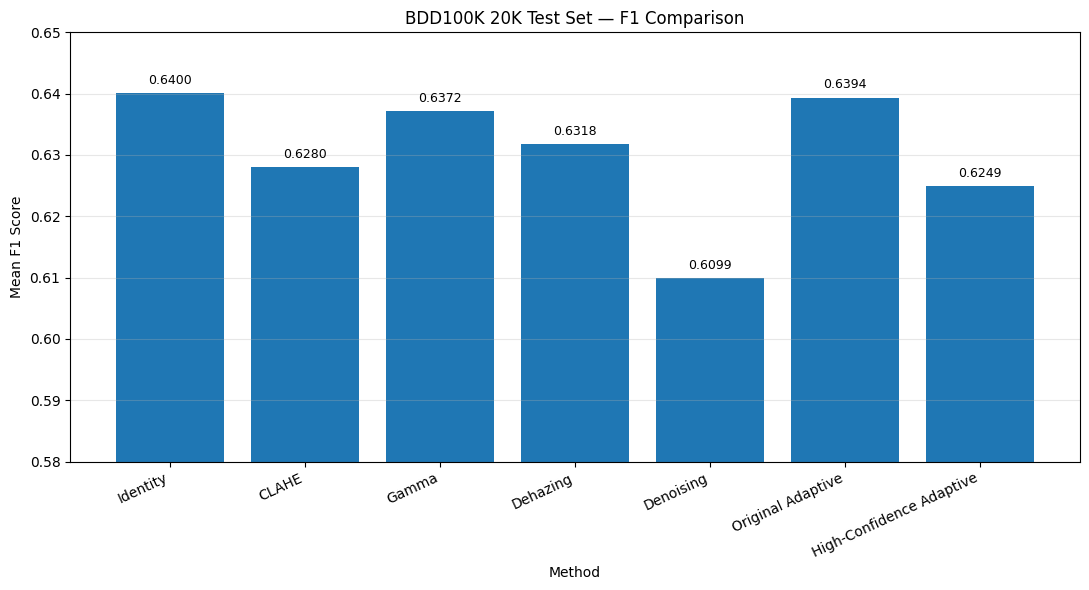

✓ Saved:
  E:\ML_Project\results\final_analysis\figures\figure_1_f1_comparison.png
  E:\ML_Project\results\final_analysis\figures\figure_1_f1_comparison.svg

Generating Figure 2 — Precision vs Recall...


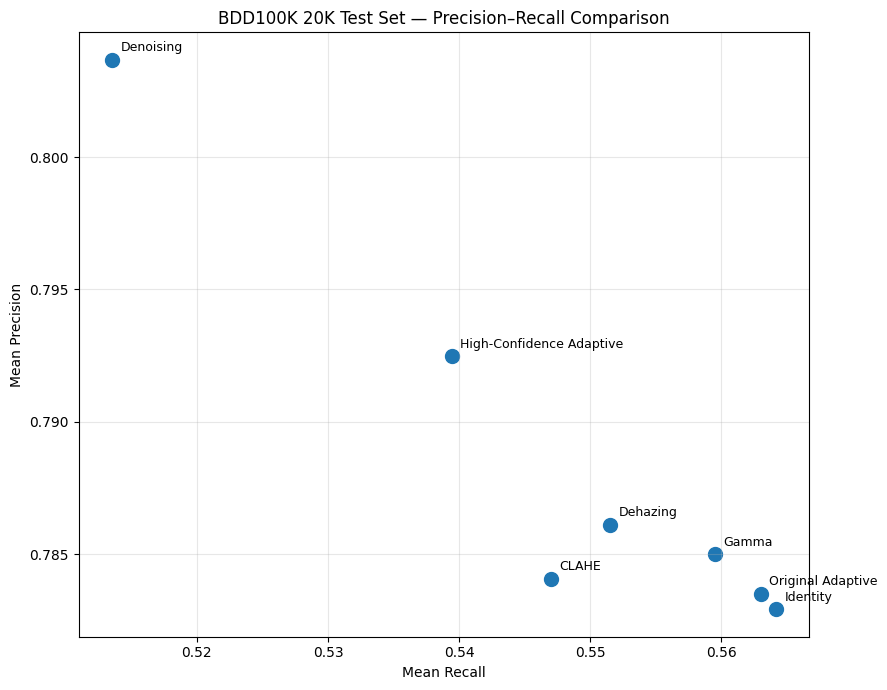

✓ Saved:
  E:\ML_Project\results\final_analysis\figures\figure_2_precision_recall.png
  E:\ML_Project\results\final_analysis\figures\figure_2_precision_recall.svg

Generating Figure 3 — Runtime comparison...


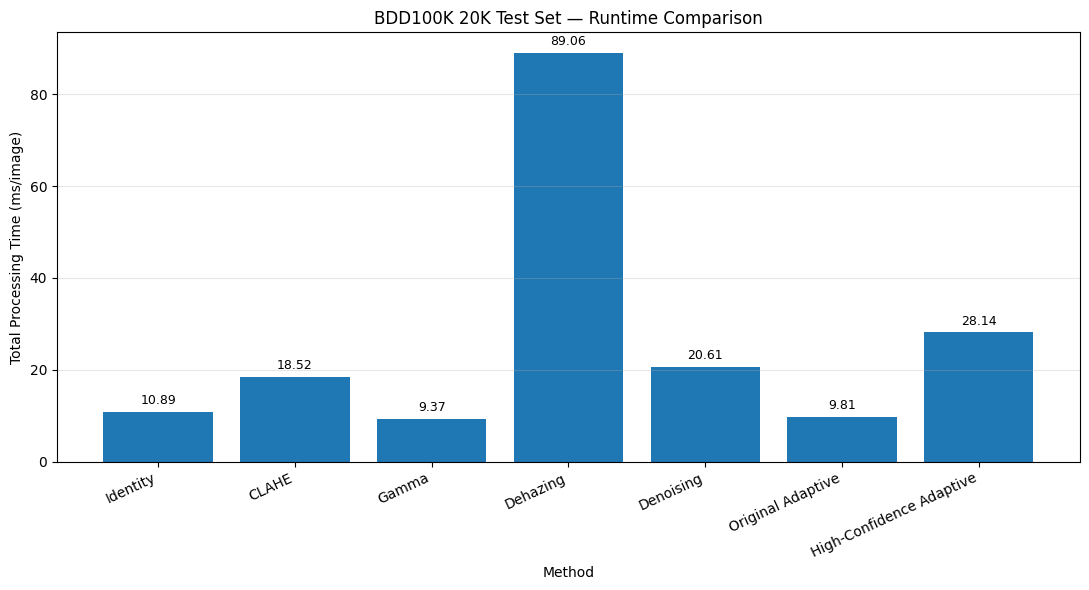

✓ Saved:
  E:\ML_Project\results\final_analysis\figures\figure_3_runtime_comparison.png
  E:\ML_Project\results\final_analysis\figures\figure_3_runtime_comparison.svg

Generating Figure 4 — F1 change...


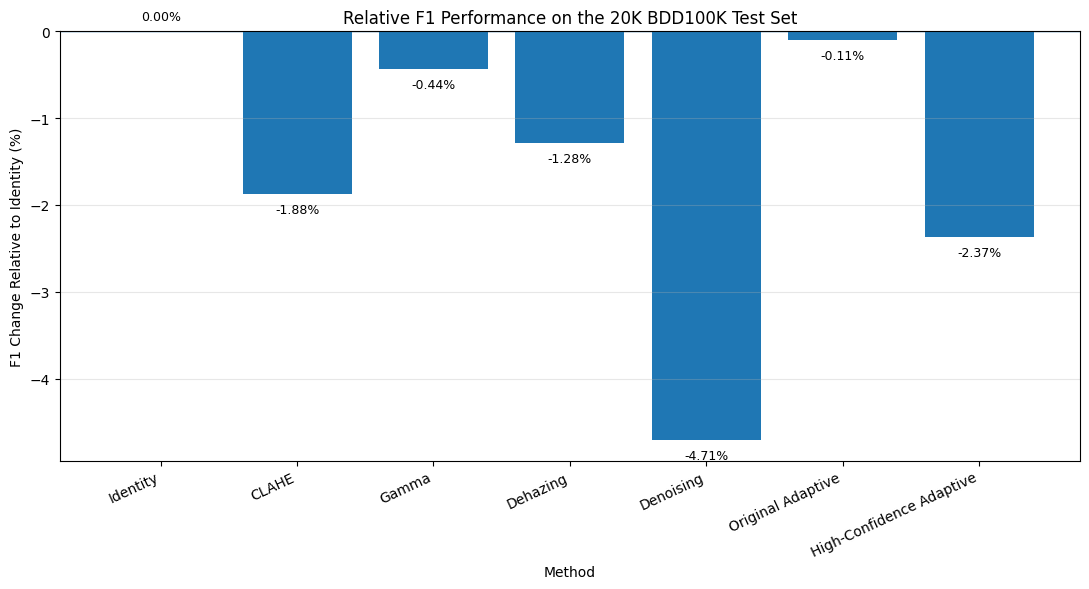

✓ Saved:
  E:\ML_Project\results\final_analysis\figures\figure_4_relative_f1_change.png
  E:\ML_Project\results\final_analysis\figures\figure_4_relative_f1_change.svg

Generating Figure 5 — Oracle gain distribution...


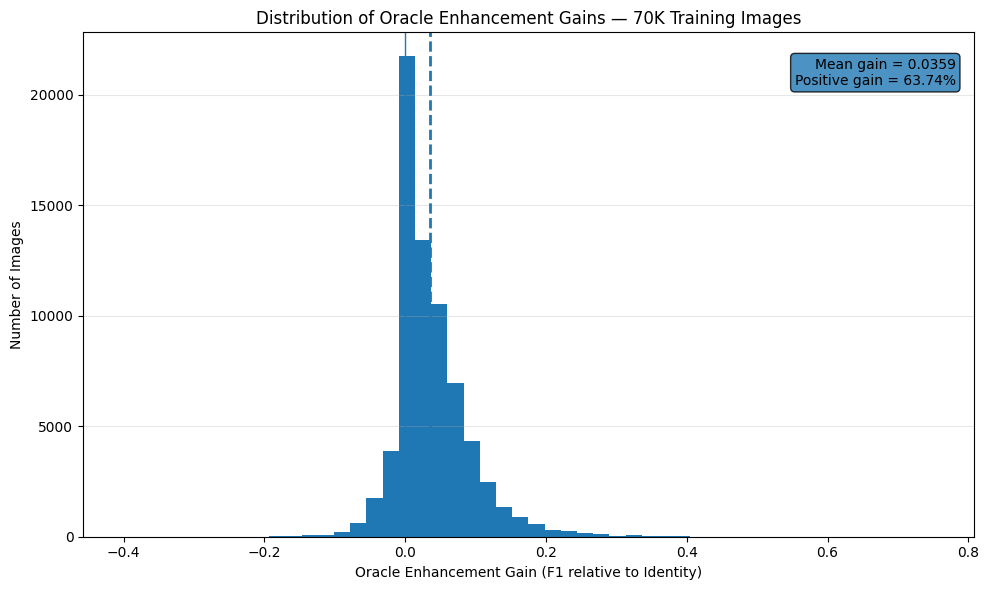

✓ Saved:
  E:\ML_Project\results\final_analysis\figures\figure_5_oracle_gain_distribution.png
  E:\ML_Project\results\final_analysis\figures\figure_5_oracle_gain_distribution.svg

FIGURE GENERATION COMPLETED

All figures saved in:
E:\ML_Project\results\final_analysis\figures

Generated figures:
1. figure_1_f1_comparison
2. figure_2_precision_recall
3. figure_3_runtime_comparison
4. figure_4_relative_f1_change
5. figure_5_oracle_gain_distribution

Both PNG (300 DPI) and SVG versions are generated.

CELL 8 COMPLETED


In [9]:
# ============================================================
# FINAL RESEARCH FIGURES
# CELL 8 — PUBLICATION / DEFENSE FIGURES
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("=" * 80)
print("FINAL RESEARCH FIGURES")
print("CELL 8 — GENERATING FIGURES")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

BASE = Path(r"E:\ML_Project")

RESULTS_DIR = (
    BASE
    / "results"
    / "final_analysis"
)

FIGURES_DIR = (
    RESULTS_DIR
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MASTER_RESULTS = (
    RESULTS_DIR
    / "final_master_results_20k.csv"
)

F1_RESULTS = (
    RESULTS_DIR
    / "final_f1_comparison_20k.csv"
)

RUNTIME_RESULTS = (
    RESULTS_DIR
    / "final_runtime_comparison_20k.csv"
)

ORACLE_SCORES = (
    BASE
    / "results"
    / "oracle_labels"
    / "oracle_scores_00000_70000.csv"
)

ORACLE_REWARDS = (
    BASE
    / "results"
    / "oracle_labels"
    / "oracle_rewards_00000_70000.csv"
)


# ============================================================
# 2. LOAD MASTER RESULTS
# ============================================================

print("\nLoading master results...")

master = pd.read_csv(
    MASTER_RESULTS
)

print(
    f"✓ Master results loaded: "
    f"{len(master)} methods"
)


# ============================================================
# 3. METHOD ORDER
# ============================================================

method_order = [

    "Identity",
    "CLAHE",
    "Gamma",
    "Dehazing",
    "Denoising",
    "Original Adaptive",
    "High-Confidence Adaptive"
]


master["Method"] = pd.Categorical(
    master["Method"],
    categories=method_order,
    ordered=True
)

master = (
    master
    .sort_values("Method")
    .reset_index(drop=True)
)


# ============================================================
# FIGURE 1
# F1 COMPARISON
# ============================================================

print("\nGenerating Figure 1 — F1 comparison...")


plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    master["Method"],
    master["F1"]
)

plt.ylabel(
    "Mean F1 Score"
)

plt.xlabel(
    "Method"
)

plt.title(
    "BDD100K 20K Test Set — F1 Comparison"
)

plt.ylim(
    0.58,
    0.65
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)


# Value labels

for bar, value in zip(
    bars,
    master["F1"]
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.001,

        f"{value:.4f}",

        ha="center",
        va="bottom",
        fontsize=9
    )


plt.tight_layout()


FIG1_PNG = (
    FIGURES_DIR
    / "figure_1_f1_comparison.png"
)

FIG1_SVG = (
    FIGURES_DIR
    / "figure_1_f1_comparison.svg"
)


plt.savefig(
    FIG1_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG1_SVG,
    format="svg",
    bbox_inches="tight"
)

plt.show()


print(
    f"✓ Saved:\n"
    f"  {FIG1_PNG}\n"
    f"  {FIG1_SVG}"
)


# ============================================================
# FIGURE 2
# PRECISION VS RECALL
# ============================================================

print("\nGenerating Figure 2 — Precision vs Recall...")


plt.figure(
    figsize=(9, 7)
)


plt.scatter(
    master["Recall"],
    master["Precision"],
    s=100
)


for _, row in master.iterrows():

    plt.annotate(
        row["Method"],
        (
            row["Recall"],
            row["Precision"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )


plt.xlabel(
    "Mean Recall"
)

plt.ylabel(
    "Mean Precision"
)

plt.title(
    "BDD100K 20K Test Set — Precision–Recall Comparison"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


FIG2_PNG = (
    FIGURES_DIR
    / "figure_2_precision_recall.png"
)

FIG2_SVG = (
    FIGURES_DIR
    / "figure_2_precision_recall.svg"
)


plt.savefig(
    FIG2_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG2_SVG,
    format="svg",
    bbox_inches="tight"
)

plt.show()


print(
    f"✓ Saved:\n"
    f"  {FIG2_PNG}\n"
    f"  {FIG2_SVG}"
)


# ============================================================
# FIGURE 3
# RUNTIME COMPARISON
# ============================================================

print("\nGenerating Figure 3 — Runtime comparison...")


plt.figure(
    figsize=(11, 6)
)


bars = plt.bar(
    master["Method"],
    master["Total_ms"]
)


plt.ylabel(
    "Total Processing Time (ms/image)"
)

plt.xlabel(
    "Method"
)

plt.title(
    "BDD100K 20K Test Set — Runtime Comparison"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)


for bar, value in zip(
    bars,
    master["Total_ms"]
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        value + 1,

        f"{value:.2f}",

        ha="center",
        va="bottom",
        fontsize=9
    )


plt.tight_layout()


FIG3_PNG = (
    FIGURES_DIR
    / "figure_3_runtime_comparison.png"
)

FIG3_SVG = (
    FIGURES_DIR
    / "figure_3_runtime_comparison.svg"
)


plt.savefig(
    FIG3_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG3_SVG,
    format="svg",
    bbox_inches="tight"
)

plt.show()


print(
    f"✓ Saved:\n"
    f"  {FIG3_PNG}\n"
    f"  {FIG3_SVG}"
)


# ============================================================
# FIGURE 4
# F1 CHANGE RELATIVE TO IDENTITY
# ============================================================

print("\nGenerating Figure 4 — F1 change...")


comparison = pd.read_csv(
    F1_RESULTS
)


comparison["Method"] = pd.Categorical(
    comparison["Method"],
    categories=method_order,
    ordered=True
)

comparison = (
    comparison
    .sort_values("Method")
)


plt.figure(
    figsize=(11, 6)
)


bars = plt.bar(
    comparison["Method"],
    comparison["F1_Change_Percent"]
)


plt.axhline(
    0,
    linewidth=1
)


plt.ylabel(
    "F1 Change Relative to Identity (%)"
)

plt.xlabel(
    "Method"
)

plt.title(
    "Relative F1 Performance on the 20K BDD100K Test Set"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)


for bar, value in zip(
    bars,
    comparison["F1_Change_Percent"]
):

    if value >= 0:

        y_position = (
            value + 0.1
        )

        va = "bottom"

    else:

        y_position = (
            value - 0.1
        )

        va = "top"


    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        y_position,

        f"{value:.2f}%",

        ha="center",
        va=va,
        fontsize=9
    )


plt.tight_layout()


FIG4_PNG = (
    FIGURES_DIR
    / "figure_4_relative_f1_change.png"
)

FIG4_SVG = (
    FIGURES_DIR
    / "figure_4_relative_f1_change.svg"
)


plt.savefig(
    FIG4_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG4_SVG,
    format="svg",
    bbox_inches="tight"
)

plt.show()


print(
    f"✓ Saved:\n"
    f"  {FIG4_PNG}\n"
    f"  {FIG4_SVG}"
)


# ============================================================
# FIGURE 5
# ORACLE GAIN DISTRIBUTION
# ============================================================

print("\nGenerating Figure 5 — Oracle gain distribution...")


if not ORACLE_REWARDS.exists():

    print(
        "⚠ Oracle reward file not found:"
    )

    print(
        ORACLE_REWARDS
    )

else:

    rewards = pd.read_csv(
        ORACLE_REWARDS
    )


    # --------------------------------------------------------
    # Find best enhancement reward column
    # --------------------------------------------------------

    possible_columns = [

        "best_enhancement_reward",

        "best_reward",

        "oracle_gain"
    ]


    gain_column = None


    for column in possible_columns:

        if column in rewards.columns:

            gain_column = column

            break


    # If not directly available,
    # calculate it from the action rewards.

    if gain_column is None:

        reward_columns = [

            "clahe_reward",
            "gamma_reward",
            "dehazing_reward",
            "denoising_reward"
        ]


        available_rewards = [

            c for c in reward_columns
            if c in rewards.columns
        ]


        if len(available_rewards) > 0:

            rewards["best_enhancement_reward"] = (
                rewards[
                    available_rewards
                ]
                .max(axis=1)
            )

            gain_column = (
                "best_enhancement_reward"
            )


    if gain_column is None:

        print(
            "⚠ Could not determine "
            "Oracle gain column."
        )

    else:

        gains = (
            rewards[gain_column]
            .dropna()
            .values
        )


        plt.figure(
            figsize=(10, 6)
        )


        plt.hist(
            gains,
            bins=50
        )


        plt.axvline(
            0,
            linewidth=1
        )


        mean_gain = np.mean(
            gains
        )


        plt.axvline(
            mean_gain,
            linestyle="--",
            linewidth=2
        )


        plt.xlabel(
            "Oracle Enhancement Gain "
            "(F1 relative to Identity)"
        )

        plt.ylabel(
            "Number of Images"
        )

        plt.title(
            "Distribution of Oracle Enhancement Gains — 70K Training Images"
        )

        plt.grid(
            axis="y",
            alpha=0.3
        )


        plt.text(
            0.98,
            0.95,

            f"Mean gain = {mean_gain:.4f}\n"
            f"Positive gain = "
            f"{np.mean(gains > 0) * 100:.2f}%",

            transform=plt.gca().transAxes,

            ha="right",
            va="top",

            bbox=dict(
                boxstyle="round",
                alpha=0.8
            )
        )


        plt.tight_layout()


        FIG5_PNG = (
            FIGURES_DIR
            / "figure_5_oracle_gain_distribution.png"
        )

        FIG5_SVG = (
            FIGURES_DIR
            / "figure_5_oracle_gain_distribution.svg"
        )


        plt.savefig(
            FIG5_PNG,
            dpi=300,
            bbox_inches="tight"
        )

        plt.savefig(
            FIG5_SVG,
            format="svg",
            bbox_inches="tight"
        )

        plt.show()


        print(
            f"✓ Saved:\n"
            f"  {FIG5_PNG}\n"
            f"  {FIG5_SVG}"
        )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FIGURE GENERATION COMPLETED")
print("=" * 80)

print(
    f"\nAll figures saved in:\n"
    f"{FIGURES_DIR}"
)

print(
    "\nGenerated figures:"
)

print(
    "1. figure_1_f1_comparison"
)

print(
    "2. figure_2_precision_recall"
)

print(
    "3. figure_3_runtime_comparison"
)

print(
    "4. figure_4_relative_f1_change"
)

print(
    "5. figure_5_oracle_gain_distribution"
)

print(
    "\nBoth PNG (300 DPI) and SVG versions "
    "are generated."
)

print("\n" + "=" * 80)
print("CELL 8 COMPLETED")
print("=" * 80)

In [10]:
# ============================================================
# FINAL RESEARCH ANALYSIS
# CELL 9 — FINAL SUMMARY + STATISTICS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 90)
print("FINAL RESEARCH ANALYSIS")
print("CELL 9 — CONSOLIDATED RESULTS + STATISTICS")
print("=" * 90)


# ============================================================
# 1. PATHS
# ============================================================

BASE = Path(r"E:\ML_Project")

ORACLE_DIR = (
    BASE
    / "results"
    / "oracle_labels"
)

FINAL_DIR = (
    BASE
    / "results"
    / "final_analysis"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. LOAD MASTER TEST RESULTS
# ============================================================

MASTER_FILE = (
    FINAL_DIR
    / "final_master_results_20k.csv"
)

master = pd.read_csv(
    MASTER_FILE
)

print("\n✓ Loaded final 20K test results")


# ============================================================
# 3. IDENTITY BASELINE
# ============================================================

identity = master[
    master["Method"] == "Identity"
].iloc[0]


identity_f1 = identity["F1"]
identity_precision = identity["Precision"]
identity_recall = identity["Recall"]


# ============================================================
# 4. FINAL TEST SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("SECTION 1 — FINAL 20K BDD100K TEST")
print("=" * 90)

print(
    f"\nIdentity baseline F1 : "
    f"{identity_f1:.6f}"
)

print(
    f"Identity Precision   : "
    f"{identity_precision:.6f}"
)

print(
    f"Identity Recall      : "
    f"{identity_recall:.6f}"
)


for _, row in master.iterrows():

    if row["Method"] == "Identity":
        continue

    delta = row["F1"] - identity_f1

    relative = (
        delta
        /
        identity_f1
        *
        100
    )

    print(
        f"\n{row['Method']}"
    )

    print(
        f"  F1        : {row['F1']:.6f}"
    )

    print(
        f"  ΔF1       : {delta:+.6f}"
    )

    print(
        f"  Relative   : {relative:+.3f}%"
    )


# ============================================================
# 5. LOAD ORACLE SCORES
# ============================================================

ORACLE_SCORE_FILE = (
    ORACLE_DIR
    / "oracle_scores_00000_70000.csv"
)

oracle_scores = pd.read_csv(
    ORACLE_SCORE_FILE
)

print("\n✓ Loaded 350K Oracle score records")


# ============================================================
# 6. ORACLE STATISTICS
# ============================================================

print("\n" + "=" * 90)
print("SECTION 2 — ORACLE ANALYSIS")
print("=" * 90)


oracle_scores["f1"] = pd.to_numeric(
    oracle_scores["f1"],
    errors="coerce"
)


# Best F1 per image

oracle_best = (
    oracle_scores
    .groupby("image")["f1"]
    .max()
)


# Identity F1

identity_scores = (
    oracle_scores[
        oracle_scores["action_id"] == 0
    ][
        ["image", "f1"]
    ]
    .rename(
        columns={
            "f1": "identity_f1"
        }
    )
)


oracle_summary = pd.DataFrame({
    "oracle_f1":
        oracle_best
}).reset_index()


oracle_summary = oracle_summary.merge(
    identity_scores,
    on="image",
    how="left"
)


oracle_summary["oracle_gain"] = (
    oracle_summary["oracle_f1"]
    -
    oracle_summary["identity_f1"]
)


# Second-best F1

second_best = (
    oracle_scores
    .groupby("image")["f1"]
    .apply(
        lambda x:
        x.nlargest(2).iloc[-1]
        if len(x) >= 2
        else np.nan
    )
)


oracle_summary = oracle_summary.merge(
    second_best.rename(
        "second_best_f1"
    ),
    on="image",
    how="left"
)


oracle_summary["margin"] = (
    oracle_summary["oracle_f1"]
    -
    oracle_summary["second_best_f1"]
)


mean_oracle_gain = (
    oracle_summary["oracle_gain"]
    .mean()
)

median_oracle_gain = (
    oracle_summary["oracle_gain"]
    .median()
)

positive_gain = (
    oracle_summary["oracle_gain"] > 0
).sum()

positive_gain_pct = (
    positive_gain
    /
    len(oracle_summary)
    *
    100
)

mean_margin = (
    oracle_summary["margin"]
    .mean()
)

median_margin = (
    oracle_summary["margin"]
    .median()
)

tie_count = (
    oracle_summary["margin"] <= 1e-12
).sum()

tie_pct = (
    tie_count
    /
    len(oracle_summary)
    *
    100
)


print(
    f"\nTraining images analyzed : "
    f"{len(oracle_summary):,}"
)

print(
    f"Oracle evaluations        : "
    f"{len(oracle_scores):,}"
)

print(
    f"Actions per image        : "
    f"{len(oracle_scores) / len(oracle_summary):.0f}"
)

print(
    f"\nMean Oracle F1            : "
    f"{oracle_summary['oracle_f1'].mean():.6f}"
)

print(
    f"Mean Identity F1         : "
    f"{oracle_summary['identity_f1'].mean():.6f}"
)

print(
    f"Mean Oracle gain         : "
    f"{mean_oracle_gain:+.6f}"
)

print(
    f"Median Oracle gain       : "
    f"{median_oracle_gain:+.6f}"
)

print(
    f"Images with positive gain: "
    f"{positive_gain:,} "
    f"({positive_gain_pct:.2f}%)"
)

print(
    f"\nMean Oracle margin       : "
    f"{mean_margin:.6f}"
)

print(
    f"Median Oracle margin     : "
    f"{median_margin:.6f}"
)

print(
    f"Exact / near ties        : "
    f"{tie_count:,} "
    f"({tie_pct:.2f}%)"
)


# ============================================================
# 7. CONFIDENCE GROUPS
# ============================================================

print("\n" + "=" * 90)
print("SECTION 3 — ORACLE CONFIDENCE")
print("=" * 90)


def confidence_group(margin):

    if margin <= 0.01:
        return "Very Low (≤0.01)"

    elif margin <= 0.02:
        return "Low (0.01–0.02)"

    elif margin <= 0.05:
        return "Moderate (0.02–0.05)"

    elif margin <= 0.10:
        return "High (0.05–0.10)"

    else:
        return "Very High (>0.10)"


oracle_summary[
    "confidence_group"
] = oracle_summary[
    "margin"
].apply(
    confidence_group
)


confidence_order = [

    "Very Low (≤0.01)",
    "Low (0.01–0.02)",
    "Moderate (0.02–0.05)",
    "High (0.05–0.10)",
    "Very High (>0.10)"
]


confidence_table = (
    oracle_summary
    .groupby(
        "confidence_group"
    )
    .agg(
        Images=("image", "count"),
        Mean_Oracle_F1=(
            "oracle_f1",
            "mean"
        ),
        Mean_Identity_F1=(
            "identity_f1",
            "mean"
        ),
        Mean_Gain=(
            "oracle_gain",
            "mean"
        ),
        Mean_Margin=(
            "margin",
            "mean"
        )
    )
    .reindex(
        confidence_order
    )
)


confidence_table[
    "Percentage"
] = (
    confidence_table["Images"]
    /
    len(oracle_summary)
    *
    100
)


print(
    confidence_table.to_string(
        float_format=lambda x:
        f"{x:.6f}"
    )
)


# ============================================================
# 8. HIGH-CONFIDENCE SUBSET
# ============================================================

high_conf = oracle_summary[
    oracle_summary["margin"] > 0.05
].copy()


print("\n" + "=" * 90)
print("HIGH-CONFIDENCE ORACLE SUBSET")
print("=" * 90)


print(
    f"\nImages                : "
    f"{len(high_conf):,}"
)

print(
    f"Percentage            : "
    f"{len(high_conf) / len(oracle_summary) * 100:.2f}%"
)

print(
    f"Mean Oracle F1        : "
    f"{high_conf['oracle_f1'].mean():.6f}"
)

print(
    f"Mean second-best F1   : "
    f"{high_conf['second_best_f1'].mean():.6f}"
)

print(
    f"Mean margin           : "
    f"{high_conf['margin'].mean():.6f}"
)

print(
    f"Mean Oracle gain      : "
    f"{high_conf['oracle_gain'].mean():+.6f}"
)


# ============================================================
# 9. POLICY VALIDATION RESULTS
# ============================================================

print("\n" + "=" * 90)
print("SECTION 4 — VALIDATION POLICY RESULTS")
print("=" * 90)


validation_files = {

    "Identity":
        ORACLE_DIR
        / "identity_validation_detection_results.csv",

    "Original Adaptive":
        ORACLE_DIR
        / "policy_validation_detection_results.csv",

    "High-Confidence Adaptive":
        ORACLE_DIR
        / "high_confidence_policy_validation_detection_results_10000.csv"
}


validation_rows = []


for method, path in validation_files.items():

    if not path.exists():

        print(
            f"⚠ Missing: {path.name}"
        )

        continue


    df = pd.read_csv(
        path
    )


    validation_rows.append({

        "Method":
            method,

        "Images":
            len(df),

        "Precision":
            df["precision"].mean(),

        "Recall":
            df["recall"].mean(),

        "F1":
            df["f1"].mean()
    })


validation = pd.DataFrame(
    validation_rows
)


print(
    validation.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}"
    )
)


# ============================================================
# 10. POLICY MODEL PERFORMANCE
# ============================================================

print("\n" + "=" * 90)
print("SECTION 5 — POLICY MODEL SIGNAL")
print("=" * 90)


MODEL_METRICS = (
    BASE
    / "results"
    / "policy_models"
    / "model_metrics.csv"
)

HIGH_MODEL_METRICS = (
    BASE
    / "results"
    / "policy_models_high_confidence"
    / "high_confidence_model_metrics.csv"
)


if MODEL_METRICS.exists():

    model_metrics = pd.read_csv(
        MODEL_METRICS
    )

    print(
        "\nOriginal policy reward models:"
    )

    print(
        model_metrics.to_string(
            index=False
        )
    )

else:

    print(
        "\nOriginal model metrics file "
        "not found."
    )


if HIGH_MODEL_METRICS.exists():

    high_model_metrics = pd.read_csv(
        HIGH_MODEL_METRICS
    )

    print(
        "\nHigh-confidence policy reward models:"
    )

    print(
        high_model_metrics.to_string(
            index=False
        )
    )

else:

    print(
        "\nHigh-confidence model metrics "
        "file not found."
    )


# ============================================================
# 11. POLICY TEST RESULTS
# ============================================================

print("\n" + "=" * 90)
print("SECTION 6 — FINAL POLICY TEST")
print("=" * 90)


original_policy = master[
    master["Method"] == "Original Adaptive"
].iloc[0]


high_policy = master[
    master["Method"] == "High-Confidence Adaptive"
].iloc[0]


print(
    f"\nIdentity F1                : "
    f"{identity_f1:.6f}"
)

print(
    f"Original Adaptive F1       : "
    f"{original_policy['F1']:.6f}"
)

print(
    f"Original Adaptive ΔF1      : "
    f"{original_policy['F1'] - identity_f1:+.6f}"
)

print(
    f"Original Adaptive relative : "
    f"{(original_policy['F1'] / identity_f1 - 1) * 100:+.3f}%"
)

print()

print(
    f"High-Confidence F1         : "
    f"{high_policy['F1']:.6f}"
)

print(
    f"High-Confidence ΔF1        : "
    f"{high_policy['F1'] - identity_f1:+.6f}"
)

print(
    f"High-Confidence relative   : "
    f"{(high_policy['F1'] / identity_f1 - 1) * 100:+.3f}%"
)


# ============================================================
# 12. FINAL CONCLUSIONS AUTOMATICALLY
# ============================================================

print("\n" + "=" * 90)
print("SECTION 7 — AUTOMATIC RESEARCH FINDINGS")
print("=" * 90)


print(
    "\n1. ORACLE POTENTIAL"
)

print(
    f"   The Oracle analysis found a mean "
    f"enhancement gain of "
    f"{mean_oracle_gain:+.4f} F1."
)

print(
    f"   {positive_gain_pct:.2f}% of training images "
    f"had a positive Oracle gain."
)


print(
    "\n2. ORACLE LABEL AMBIGUITY"
)

print(
    f"   {tie_pct:.2f}% of images had "
    f"an exact/near tie between the best "
    f"and second-best actions."
)

print(
    f"   Mean Oracle margin was "
    f"{mean_margin:.4f}."
)


print(
    "\n3. FINAL BASELINE"
)

print(
    f"   Frozen YOLO26n Identity achieved "
    f"F1 = {identity_f1:.4f} "
    f"on the held-out 20K test set."
)


print(
    "\n4. ORIGINAL ADAPTIVE POLICY"
)

if original_policy["F1"] > identity_f1:

    print(
        "   The adaptive policy improved "
        "overall test F1."
    )

else:

    print(
        "   The adaptive policy did not "
        "improve overall test F1."
    )


print(
    f"   Final F1 = "
    f"{original_policy['F1']:.4f}"
)

print(
    f"   Relative change = "
    f"{(original_policy['F1'] / identity_f1 - 1) * 100:+.3f}%"
)


print(
    "\n5. HIGH-CONFIDENCE POLICY"
)

if high_policy["F1"] > identity_f1:

    print(
        "   The high-confidence policy "
        "improved overall test F1."
    )

else:

    print(
        "   The high-confidence policy "
        "did not improve overall test F1."
    )


print(
    f"   Final F1 = "
    f"{high_policy['F1']:.4f}"
)


print(
    "\n6. OVERALL INTERPRETATION"
)

print(
    "   The experiments demonstrate that "
    "adaptive enhancement has measurable "
    "per-image potential, but the current "
    "IQA-based LightGBM policy does not "
    "reliably generalize the Oracle advantage "
    "to the unseen BDD100K test set."
)


# ============================================================
# 13. SAVE CONSOLIDATED DATA
# ============================================================

print("\n" + "=" * 90)
print("SAVING FINAL ANALYSIS FILES")
print("=" * 90)


ORACLE_SUMMARY_FILE = (
    FINAL_DIR
    / "oracle_summary_70000.csv"
)

CONFIDENCE_FILE = (
    FINAL_DIR
    / "oracle_confidence_summary.csv"
)

VALIDATION_FILE = (
    FINAL_DIR
    / "validation_policy_summary.csv"
)


oracle_summary.to_csv(
    ORACLE_SUMMARY_FILE,
    index=False
)


confidence_table.to_csv(
    CONFIDENCE_FILE
)


validation.to_csv(
    VALIDATION_FILE,
    index=False
)


print(
    f"✓ Oracle summary:\n"
    f"  {ORACLE_SUMMARY_FILE}"
)

print(
    f"\n✓ Confidence summary:\n"
    f"  {CONFIDENCE_FILE}"
)

print(
    f"\n✓ Validation summary:\n"
    f"  {VALIDATION_FILE}"
)


# ============================================================
# 14. SAVE HUMAN-READABLE REPORT
# ============================================================

REPORT_FILE = (
    FINAL_DIR
    / "final_research_summary.txt"
)


with open(
    REPORT_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "FINAL RESEARCH SUMMARY\n"
    )

    f.write(
        "=" * 80
        + "\n\n"
    )

    f.write(
        "PROJECT:\n"
        "Enhancing the Robustness of YOLO-Based "
        "Object Detection under Adverse Weather Conditions\n\n"
    )

    f.write(
        "FINAL TEST RESULTS\n"
    )

    f.write(
        "-" * 80
        + "\n"
    )

    f.write(
        master.to_string(
            index=False
        )
    )

    f.write(
        "\n\n"
    )

    f.write(
        "ORACLE STATISTICS\n"
    )

    f.write(
        "-" * 80
        + "\n"
    )

    f.write(
        f"Training images: {len(oracle_summary):,}\n"
    )

    f.write(
        f"Oracle evaluations: {len(oracle_scores):,}\n"
    )

    f.write(
        f"Mean Oracle F1: "
        f"{oracle_summary['oracle_f1'].mean():.6f}\n"
    )

    f.write(
        f"Mean Identity F1: "
        f"{oracle_summary['identity_f1'].mean():.6f}\n"
    )

    f.write(
        f"Mean Oracle gain: "
        f"{mean_oracle_gain:+.6f}\n"
    )

    f.write(
        f"Positive Oracle gain: "
        f"{positive_gain_pct:.2f}%\n"
    )

    f.write(
        f"Mean Oracle margin: "
        f"{mean_margin:.6f}\n"
    )

    f.write(
        f"Exact/near ties: "
        f"{tie_pct:.2f}%\n"
    )

    f.write(
        "\n"
    )

    f.write(
        "FINAL INTERPRETATION\n"
    )

    f.write(
        "-" * 80
        + "\n"
    )

    f.write(
        "The Oracle experiment demonstrates measurable "
        "per-image enhancement potential. However, "
        "the current IQA-based LightGBM adaptive policy "
        "does not reliably generalize this Oracle "
        "advantage to the unseen BDD100K test set. "
        "The original adaptive policy approximately "
        "matches the frozen YOLO26n baseline but "
        "does not improve overall F1.\n"
    )


print(
    f"\n✓ Human-readable report:\n"
    f"  {REPORT_FILE}"
)


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 90)
print("CELL 9 COMPLETED")
print("=" * 90)

print(
    "\nAll major experimental statistics are now "
    "consolidated."
)

print(
    "\nNEXT STEP:"
)

print(
    "Results & Discussion + Defense Preparation"
)

print("=" * 90)

FINAL RESEARCH ANALYSIS
CELL 9 — CONSOLIDATED RESULTS + STATISTICS

✓ Loaded final 20K test results

SECTION 1 — FINAL 20K BDD100K TEST

Identity baseline F1 : 0.640032
Identity Precision   : 0.782915
Identity Recall      : 0.564167

CLAHE
  F1        : 0.628003
  ΔF1       : -0.012029
  Relative   : -1.879%

Gamma
  F1        : 0.637230
  ΔF1       : -0.002802
  Relative   : -0.438%

Dehazing
  F1        : 0.631808
  ΔF1       : -0.008224
  Relative   : -1.285%

Denoising
  F1        : 0.609894
  ΔF1       : -0.030138
  Relative   : -4.709%

Original Adaptive
  F1        : 0.639359
  ΔF1       : -0.000673
  Relative   : -0.105%

High-Confidence Adaptive
  F1        : 0.624870
  ΔF1       : -0.015162
  Relative   : -2.369%

✓ Loaded 350K Oracle score records

SECTION 2 — ORACLE ANALYSIS

Training images analyzed : 70,000
Oracle evaluations        : 350,000
Actions per image        : 5

Mean Oracle F1            : 0.684417
Mean Identity F1         : 0.645028
Mean Oracle gain         : +